# Problem Analysis

This notebook analyzes the Round 4 manual challenge **"Vanilla Just Isn't Exotic Enough"**.

You are given one underlying product, `AETHER_CRYSTAL`, and several options written on it:

- the underlying `AC`,
- 2-week and 3-week vanilla calls and puts,
- a 3-week chooser option,
- a 3-week binary put,
- a 3-week knock-out put.

The challenge is standalone. You choose your buy/sell orders at the start of the round and hold all positions to expiry. There is no dynamic trading and no connection to Round 1 trading data.

The underlying follows a discrete-time Geometric Brownian Motion with:

- initial spot approximately 50,
- zero risk-neutral drift,
- annualized volatility 251%,
- 252 trading days per year,
- 4 simulation steps per trading day.

The goal is to estimate the fair value of each contract, compare that fair value with the displayed bid/ask, and construct a portfolio with positive expected PnL while controlling risk.

For a buy order:

$$
\text{PnL} = \text{payoff} - \text{ask}.
$$

For a sell order:

$$
\text{PnL} = \text{bid} - \text{payoff}.
$$

The challenge multiplies per-contract PnL by a contract size of 3000.

# II: Simulation of possible price paths

## Step 1. Import packages

Run this cell first. The notebook only uses standard scientific Python packages: `numpy`, `pandas`, and `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## Step 2. Set model assumptions

The bid/ask of the underlying is 49.975 / 50.025, so the midpoint is 50. This is why the simulation uses `S0 = 50.0`.

The challenge states that 1 trading year has `252 * 4 = 1008` simulation steps.

- 2 weeks = 10 trading days = 40 steps.
- 3 weeks = 15 trading days = 60 steps.

In [2]:
S0 = 50.0
SIGMA = 2.51

TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

CONTRACT_SIZE = 3000

STEPS_2W = int(round(2 * 5 * STEPS_PER_DAY))
STEPS_3W = int(round(3 * 5 * STEPS_PER_DAY))
DT = 1 / STEPS_PER_YEAR

N_PATHS = 500_000
RANDOM_SEED = 42

print("STEPS_PER_YEAR:", STEPS_PER_YEAR)
print("STEPS_2W:", STEPS_2W)
print("STEPS_3W:", STEPS_3W)
print("DT:", DT)

STEPS_PER_YEAR: 1008
STEPS_2W: 40
STEPS_3W: 60
DT: 0.000992063492063492


## Step 3. Enter the market table

This cell records the products, bid/ask prices, maximum sizes, strikes, expiries, and exotic-option parameters.

Sign convention later in the notebook:

- positive quantity means buy,
- negative quantity means sell.

In [3]:
contracts = {
    "AC": {
        "type": "underlying",
        "bid": 49.975,
        "ask": 50.025,
        "max_buy": 200,
        "max_sell": 200,
    },
    "AC_50_P": {
        "type": "put",
        "K": 50,
        "expiry_steps": STEPS_3W,
        "bid": 12.00,
        "ask": 12.05,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_C": {
        "type": "call",
        "K": 50,
        "expiry_steps": STEPS_3W,
        "bid": 12.00,
        "ask": 12.05,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_35_P": {
        "type": "put",
        "K": 35,
        "expiry_steps": STEPS_3W,
        "bid": 4.33,
        "ask": 4.35,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_40_P": {
        "type": "put",
        "K": 40,
        "expiry_steps": STEPS_3W,
        "bid": 6.50,
        "ask": 6.55,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_45_P": {
        "type": "put",
        "K": 45,
        "expiry_steps": STEPS_3W,
        "bid": 9.05,
        "ask": 9.10,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_60_C": {
        "type": "call",
        "K": 60,
        "expiry_steps": STEPS_3W,
        "bid": 8.80,
        "ask": 8.85,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_P_2": {
        "type": "put",
        "K": 50,
        "expiry_steps": STEPS_2W,
        "bid": 9.70,
        "ask": 9.75,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_C_2": {
        "type": "call",
        "K": 50,
        "expiry_steps": STEPS_2W,
        "bid": 9.70,
        "ask": 9.75,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_50_CO": {
        "type": "chooser",
        "K": 50,
        "choose_steps": STEPS_2W,
        "expiry_steps": STEPS_3W,
        "bid": 22.20,
        "ask": 22.30,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_40_BP": {
        "type": "binary_put",
        "K": 40,
        "payout": 10,
        "expiry_steps": STEPS_3W,
        "bid": 5.00,
        "ask": 5.10,
        "max_buy": 50,
        "max_sell": 50,
    },
    "AC_45_KO": {
        "type": "ko_put",
        "K": 45,
        "barrier": 35,
        "expiry_steps": STEPS_3W,
        "bid": 0.15,
        "ask": 0.175,
        "max_buy": 500,
        "max_sell": 500,
    },
}

market_table = pd.DataFrame.from_dict(contracts, orient="index")
market_table

,type,bid,ask,max_buy,max_sell,K,expiry_steps,choose_steps,payout,barrier
AC,underlying,49.975,50.025,200,200,NaN,NaN,NaN,NaN,NaN
AC_50_P,put,12.000,12.050,50,50,50.0,60.0,NaN,NaN,NaN
AC_50_C,call,12.000,12.050,50,50,50.0,60.0,NaN,NaN,NaN
AC_35_P,put,4.330,4.350,50,50,35.0,60.0,NaN,NaN,NaN
AC_40_P,put,6.500,6.550,50,50,40.0,60.0,NaN,NaN,NaN
AC_45_P,put,9.050,9.100,50,50,45.0,60.0,NaN,NaN,NaN
AC_60_C,call,8.800,8.850,50,50,60.0,60.0,NaN,NaN,NaN
AC_50_P_2,put,9.700,9.750,50,50,50.0,40.0,NaN,NaN,NaN
AC_50_C_2,call,9.700,9.750,50,50,50.0,40.0,NaN,NaN,NaN
AC_50_CO,chooser,22.200,22.300,50,50,50.0,60.0,40.0,NaN,NaN


## Step 4. Simulate the underlying paths

The exact discrete GBM update is:

$$
S_{t+\Delta t} = S_t \exp \left((\mu -\frac{\sigma^2}{2})\Delta t + \sigma\sqrt{\Delta t} \; \mathrm{Z}\right),
$$

where $\mathrm{Z}\sim N(0,1)$.

The drift is zero in the GBM equation (i.e. $\mu = 0$), but the log update contains the usual $-\frac12\sigma^2\Delta t$ adjustment.

In [4]:
def simulate_gbm_paths(S0, sigma, n_paths, n_steps, dt, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))
    log_returns = (-0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_returns, axis=1)
    paths = S0 * np.exp(log_paths)
    paths = np.concatenate([np.full((n_paths, 1), S0), paths], axis=1)
    return paths

paths = simulate_gbm_paths(
    S0=S0,
    sigma=SIGMA,
    n_paths=N_PATHS,
    n_steps=STEPS_3W,
    dt=DT,
    seed=RANDOM_SEED,
)

S_2W = paths[:, STEPS_2W]
S_3W = paths[:, STEPS_3W]

print("paths shape:", paths.shape)
print("Mean S_2W:", S_2W.mean())
print("Mean S_3W:", S_3W.mean())
print("Median S_3W:", np.median(S_3W))

paths shape: (500000, 61)
Mean S_2W: 49.997443931657685
Mean S_3W: 49.97996961628291
Median S_3W: 41.48102511960558


## Step 5. Visualize the simulated terminal distribution

This helps you understand why option prices are large. The volatility is extremely high, so the right tail can be very large even over only 3 weeks.

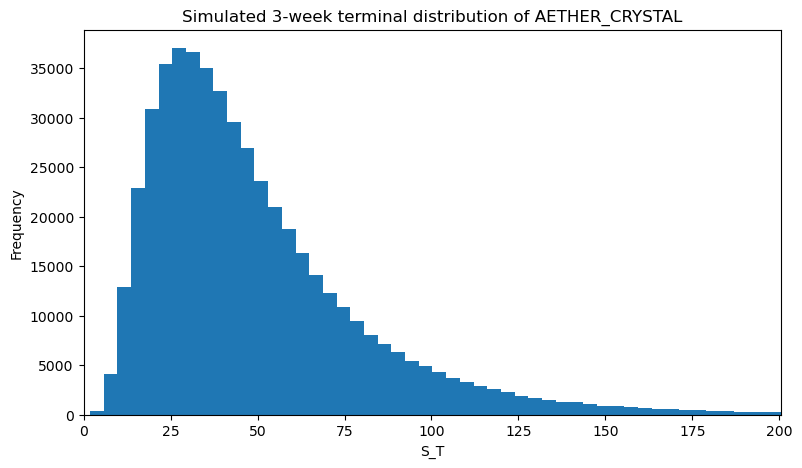

count    500000.000000
mean         49.979970
std          33.690336
min           1.857543
1%            9.993051
5%           15.136069
10%          18.949434
50%          41.481025
90%          90.807993
95%         113.372067
99%         172.005227
max         789.154372
dtype: float64

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(S_3W, bins=200)
plt.title("Simulated 3-week terminal distribution of AETHER_CRYSTAL")
plt.xlabel("S_T")
plt.ylabel("Frequency")
plt.xlim(0, np.percentile(S_3W, 99.5))
plt.show()

summary = pd.Series(S_3W).describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])
summary

# III: Payoff definitions and Risk stastictis 

## Step 6. Define payoff functions

This cell implements the payoff rule for each product.

Important interpretations used here:

1. The chooser option chooses call if `S_choose >= K`, otherwise put.
2. The binary put pays 10 if `S_T < 40`, otherwise 0.
3. The knock-out put has strike 45 and barrier 35. If the path ever goes below 35 at a discrete simulation point, it becomes worthless.

In [6]:
def payoff_for_contract(name, contract, paths):
    ctype = contract["type"]

    if ctype == "underlying":
        return paths[:, STEPS_3W]

    if ctype == "call":
        K = contract["K"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return np.maximum(ST - K, 0)

    if ctype == "put":
        K = contract["K"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return np.maximum(K - ST, 0)

    if ctype == "binary_put":
        K = contract["K"]
        payout = contract["payout"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        return payout * (ST < K)

    if ctype == "ko_put":
        K = contract["K"]
        barrier = contract["barrier"]
        T = contract["expiry_steps"]
        ST = paths[:, T]
        path_until_T = paths[:, :T + 1]
        knocked_out = np.any(path_until_T < barrier, axis=1)
        vanilla_put_payoff = np.maximum(K - ST, 0)
        return np.where(knocked_out, 0, vanilla_put_payoff)

    if ctype == "chooser":
        K = contract["K"]
        choose_t = contract["choose_steps"]
        T = contract["expiry_steps"]
        S_choose = paths[:, choose_t]
        ST = paths[:, T]
        call_payoff = np.maximum(ST - K, 0)
        put_payoff = np.maximum(K - ST, 0)
        return np.where(S_choose >= K, call_payoff, put_payoff)

    raise ValueError(f"Unknown contract type: {ctype}")

payoffs = {name: payoff_for_contract(name, contract, paths) for name, contract in contracts.items()}
payoff_df = pd.DataFrame(payoffs)
payoff_df.head()

,AC,AC_50_P,AC_50_C,AC_35_P,AC_40_P,AC_45_P,AC_60_C,AC_50_P_2,AC_50_C_2,AC_50_CO,AC_40_BP,AC_45_KO
0,56.497627,0.000000,6.497627,0.000000,0.000000,0.000000,0.0,0.199424,0.000000,0.000000,0,0.000000
1,17.146846,32.853154,0.000000,17.853154,22.853154,27.853154,0.0,28.243271,0.000000,32.853154,10,0.000000
2,32.778038,17.221962,0.000000,2.221962,7.221962,12.221962,0.0,13.938588,0.000000,17.221962,10,0.000000
3,38.105905,11.894095,0.000000,0.000000,1.894095,6.894095,0.0,0.000000,1.970482,0.000000,10,6.894095
4,38.174960,11.825040,0.000000,0.000000,1.825040,6.825040,0.0,0.000000,7.106127,0.000000,10,0.000000


## Step 7. Compute fair values and bid/ask edges

For each contract:

- buy edge = fair value - ask,
- sell edge = bid - fair value.

A positive buy edge means the contract looks cheap. A positive sell edge means the contract looks expensive.

In [7]:
rows = []

for name, contract in contracts.items():
    fair = payoff_df[name].mean()
    bid = contract["bid"]
    ask = contract["ask"]
    buy_edge = fair - ask
    sell_edge = bid - fair

    rows.append({
        "contract": name,
        "type": contract["type"],
        "fair_value": fair,
        "bid": bid,
        "ask": ask,
        "buy_edge": buy_edge,
        "sell_edge": sell_edge,
        "best_side": "BUY" if buy_edge > sell_edge else "SELL",
        "best_edge": max(buy_edge, sell_edge),
        "max_buy": contract["max_buy"],
        "max_sell": contract["max_sell"],
    })

edge_table = pd.DataFrame(rows).sort_values("best_edge", ascending=False).reset_index(drop=True)
edge_table

,contract,type,fair_value,bid,ask,buy_edge,sell_edge,best_side,best_edge,max_buy,max_sell
0,AC_50_CO,chooser,21.864573,22.200,22.300,-0.435427,0.335427,SELL,0.335427,50,50
1,AC_40_BP,binary_put,4.764500,5.000,5.100,-0.335500,0.235500,SELL,0.235500,50,50
2,AC_50_P_2,put,9.865477,9.700,9.750,0.115477,-0.165477,BUY,0.115477,50,50
3,AC_50_C_2,call,9.862921,9.700,9.750,0.112921,-0.162921,BUY,0.112921,50,50
4,AC_60_C,call,8.760441,8.800,8.850,-0.089559,0.039559,SELL,0.039559,50,50
5,AC_45_KO,ko_put,0.205626,0.150,0.175,0.030626,-0.055626,BUY,0.030626,500,500
6,AC_50_C,call,11.994400,12.000,12.050,-0.055600,0.005600,SELL,0.005600,50,50
7,AC_35_P,put,4.330159,4.330,4.350,-0.019841,-0.000159,SELL,-0.000159,50,50
8,AC_40_P,put,6.500217,6.500,6.550,-0.049783,-0.000217,SELL,-0.000217,50,50
9,AC,underlying,49.979970,49.975,50.025,-0.045030,-0.004970,SELL,-0.004970,200,200


## Step 8. Compute single-contract risk statistics

This step checks the distribution of PnL for buying or selling one unit of each contract.

This is important because selling options may look good in expectation but can have large left-tail losses.

In [8]:
risk_rows = []

for name, contract in contracts.items():
    payoff = payoff_df[name].values
    bid = contract["bid"]
    ask = contract["ask"]

    buy_pnl = payoff - ask
    sell_pnl = bid - payoff

    risk_rows.append({
        "contract": name,
        "buy_mean": buy_pnl.mean(),
        "buy_std": buy_pnl.std(),
        "buy_p5": np.percentile(buy_pnl, 5),
        "buy_p1": np.percentile(buy_pnl, 1),
        "sell_mean": sell_pnl.mean(),
        "sell_std": sell_pnl.std(),
        "sell_p5": np.percentile(sell_pnl, 5),
        "sell_p1": np.percentile(sell_pnl, 1),
    })

risk_table = pd.DataFrame(risk_rows)
risk_table

,contract,buy_mean,buy_std,buy_p5,buy_p1,sell_mean,sell_std,sell_p5,sell_p1
0,AC,-0.045030,33.690302,-34.888931,-40.031949,-0.004970,33.690302,-63.397067,-122.030227
1,AC_50_P,-0.035570,12.609021,-12.050000,-12.050000,-0.014430,12.609021,-22.863931,-28.006949
2,AC_50_C,-0.055600,26.226652,-12.050000,-12.050000,0.005600,26.226652,-51.372067,-110.005227
3,AC_35_P,-0.019841,6.931460,-4.350000,-4.350000,-0.000159,6.931460,-15.533931,-20.676949
4,AC_40_P,-0.049783,8.850796,-6.550000,-6.550000,-0.000217,8.850796,-18.363931,-23.506949
5,AC_45_P,-0.022774,10.759255,-9.100000,-9.100000,-0.027226,10.759255,-20.813931,-25.956949
6,AC_60_C,-0.089559,23.434963,-8.850000,-8.850000,0.039559,23.434963,-44.572067,-103.205227
7,AC_50_P_2,0.115477,10.968541,-9.750000,-9.750000,-0.165477,10.968541,-20.932151,-26.490229
8,AC_50_C_2,0.112921,19.853086,-9.750000,-9.750000,-0.162921,19.853086,-40.830503,-81.002295
9,AC_50_CO,-0.435427,24.773987,-22.300000,-22.300000,0.335427,24.773987,-40.837062,-99.728318


## Step 9. Estimate delta for each contract

Delta measures approximate exposure to the underlying.

This notebook estimates delta by bumping `S0` slightly up and down and reusing the same random numbers for both simulations.

The underlying has delta 1 by definition.

In [9]:
def estimate_delta(contract_name, contract, n_paths=200_000, bump=0.10, seed=123):
    if contract["type"] == "underlying":
        return 1.0

    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, STEPS_3W))
    log_returns = (-0.5 * SIGMA**2) * DT + SIGMA * np.sqrt(DT) * Z
    log_paths = np.cumsum(log_returns, axis=1)

    def make_paths(start_price):
        p = start_price * np.exp(log_paths)
        p = np.concatenate([np.full((n_paths, 1), start_price), p], axis=1)
        return p

    paths_up = make_paths(S0 + bump)
    paths_down = make_paths(S0 - bump)

    payoff_up = payoff_for_contract(contract_name, contract, paths_up).mean()
    payoff_down = payoff_for_contract(contract_name, contract, paths_down).mean()

    return (payoff_up - payoff_down) / (2 * bump)


deltas = {name: estimate_delta(name, contract) for name, contract in contracts.items()}
delta_table = pd.DataFrame({"contract": list(deltas.keys()), "delta": list(deltas.values())})
delta_table

,contract,delta
0,AC,1.000000
1,AC_50_P,-0.379167
2,AC_50_C,0.619433
3,AC_35_P,-0.186528
4,AC_40_P,-0.250830
5,AC_45_P,-0.315073
6,AC_60_C,0.499530
7,AC_50_P_2,-0.402081
8,AC_50_C_2,0.597181
9,AC_50_CO,0.206949


## Step 10. Define portfolio PnL and portfolio statistics

This cell lets you evaluate any portfolio.

Again, positive quantity means buy, and negative quantity means sell.

In [10]:
def portfolio_pnl(positions):
    total = np.zeros(len(payoff_df))

    for name, qty in positions.items():
        if qty == 0:
            continue

        contract = contracts[name]
        payoff = payoff_df[name].values

        if qty > 0:
            total += qty * (payoff - contract["ask"])
        else:
            total += (-qty) * (contract["bid"] - payoff)

    return CONTRACT_SIZE * total

def portfolio_delta(positions):
    return CONTRACT_SIZE * sum(qty * deltas[name] for name, qty in positions.items())


def portfolio_stats(positions):
    pnl = portfolio_pnl(positions)
    return {
        "mean": pnl.mean(),
        "std": pnl.std(),
        "p10": np.percentile(pnl, 10),
        "p5": np.percentile(pnl, 5),
        "p1": np.percentile(pnl, 1),
        "min": pnl.min(),
        "delta": portfolio_delta(positions),
        "sharpe_like": pnl.mean() / pnl.std() if pnl.std() > 0 else np.nan,
    }


def display_portfolio(name, positions):
    clean_positions = {k: v for k, v in positions.items() if v != 0}
    stats = portfolio_stats(clean_positions)
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Positions:")
    for contract, qty in clean_positions.items():
        side = "BUY" if qty > 0 else "SELL"
        print(f"  {contract}: {side} {abs(qty)}")
    print("Stats:")
    for k, v in stats.items():
        print(f"  {k}: {v:,.2f}")
    return stats

## Step 11. Build a naive max-edge portfolio

This portfolio takes the maximum allowed position in the best edge direction for every product whose best edge is positive.

This is useful as a benchmark, but it may be too risky.

In [11]:
naive_positions = {}

for _, row in edge_table.iterrows():
    name = row["contract"]
    if row["best_edge"] <= 0:
        naive_positions[name] = 0
    elif row["best_side"] == "BUY":
        naive_positions[name] = contracts[name]["max_buy"]
    else:
        naive_positions[name] = -contracts[name]["max_sell"]

display_portfolio("Naive max-edge portfolio", naive_positions)

Naive max-edge portfolio
Positions:
  AC_50_CO: SELL 50
  AC_40_BP: SELL 50
  AC_50_P_2: BUY 50
  AC_50_C_2: BUY 50
  AC_60_C: SELL 50
  AC_45_KO: BUY 500
  AC_50_C: SELL 50
Stats:
  mean: 172,611.57
  std: 9,391,048.31
  p10: -8,204,827.05
  p5: -16,972,127.25
  p1: -39,882,051.30
  min: -275,821,659.10
  delta: -136,000.73
  sharpe_like: 0.02


{'mean': np.float64(172611.56778377967),
 'std': np.float64(9391048.312497322),
 'p10': np.float64(-8204827.050347032),
 'p5': np.float64(-16972127.251315374),
 'p1': np.float64(-39882051.30429205),
 'min': np.float64(-275821659.1010102),
 'delta': np.float64(-136000.73122796082),
 'sharpe_like': np.float64(0.01838043656468825)}

## Step 12. Delta hedge the portfolio using the underlying

This cell automatically chooses an `AC` quantity to reduce the portfolio's delta.

Because the maximum `AC` volume is only 200, the hedge may not fully remove delta.

In [12]:
def delta_hedge_with_underlying(positions):
    new_positions = dict(positions)

    option_delta_units = 0.0
    for name, qty in new_positions.items():
        if name == "AC":
            continue
        option_delta_units += qty * deltas[name]

    hedge_qty = int(round(-option_delta_units))
    hedge_qty = max(-contracts["AC"]["max_sell"], hedge_qty)
    hedge_qty = min(contracts["AC"]["max_buy"], hedge_qty)

    new_positions["AC"] = hedge_qty
    return new_positions

hedged_naive_positions = delta_hedge_with_underlying(naive_positions)
display_portfolio("Delta-hedged naive portfolio", hedged_naive_positions)

Delta-hedged naive portfolio
Positions:
  AC_50_CO: SELL 50
  AC_40_BP: SELL 50
  AC_50_P_2: BUY 50
  AC_50_C_2: BUY 50
  AC_60_C: SELL 50
  AC_45_KO: BUY 500
  AC_50_C: SELL 50
  AC: BUY 45
Stats:
  mean: 166,532.47
  std: 6,326,619.45
  p10: -4,565,074.90
  p5: -8,650,108.90
  p1: -23,719,174.07
  min: -176,039,193.92
  delta: -1,000.73
  sharpe_like: 0.03


{'mean': np.float64(166532.46598197272),
 'std': np.float64(6326619.447463118),
 'p10': np.float64(-4565074.902380136),
 'p5': np.float64(-8650108.904674122),
 'p1': np.float64(-23719174.073654253),
 'min': np.float64(-176039193.91506672),
 'delta': np.float64(-1000.7312279608129),
 'sharpe_like': np.float64(0.02632250404262103)}

## Step 13. Test important relative-value portfolios

These portfolios compare related products directly.

Examples:

- chooser versus call + put,
- binary put versus vanilla put,
- knock-out put versus vanilla put.

These are useful because they reduce pure directional guessing and focus on relative mispricing.

In [13]:
relative_value_portfolios = {
    "Long chooser, short 3-week 50 call and put": {
        "AC_50_CO": 50,
        "AC_50_C": -50,
        "AC_50_P": -50,
    },
    "Short chooser, long 3-week 50 call and put": {
        "AC_50_CO": -50,
        "AC_50_C": 50,
        "AC_50_P": 50,
    },
    "Long binary put, short 40 put": {
        "AC_40_BP": 50,
        "AC_40_P": -50,
    },
    "Short binary put, long 40 put": {
        "AC_40_BP": -50,
        "AC_40_P": 50,
    },
    "Long KO put, short 45 vanilla put": {
        "AC_45_KO": 500,
        "AC_45_P": -50,
    },
    "Short KO put, long 45 vanilla put": {
        "AC_45_KO": -500,
        "AC_45_P": 50,
    },
}

relative_results = []

for name, positions in relative_value_portfolios.items():
    hedged_positions = delta_hedge_with_underlying(positions)
    stats = display_portfolio(name + " with AC delta hedge", hedged_positions)
    relative_results.append({"name": name, **stats, "positions": hedged_positions})

relative_results_df = pd.DataFrame(relative_results).sort_values("mean", ascending=False)
relative_results_df[["name", "mean", "std", "p5", "p1", "delta", "sharpe_like"]]

Long chooser, short 3-week 50 call and put with AC delta hedge
Positions:
  AC_50_CO: BUY 50
  AC_50_C: SELL 50
  AC_50_P: SELL 50
  AC: BUY 2
Stats:
  mean: -66,908.81
  std: 944,079.84
  p10: -1,012,449.16
  p5: -2,081,144.65
  p1: -3,992,132.33
  min: -20,039,360.02
  delta: 1,002.54
  sharpe_like: -0.07
Short chooser, long 3-week 50 call and put with AC delta hedge
Positions:
  AC_50_CO: SELL 50
  AC_50_C: BUY 50
  AC_50_P: BUY 50
  AC: SELL 2
Stats:
  mean: 36,608.81
  std: 944,079.84
  p10: -523,073.37
  p5: -663,372.37
  p1: -1,016,719.91
  min: -4,720,076.23
  delta: -1,002.54
  sharpe_like: 0.04
Long binary put, short 40 put with AC delta hedge
Positions:
  AC_40_BP: BUY 50
  AC_40_P: SELL 50
  AC: SELL 7
Stats:
  mean: -50,461.91
  std: 913,022.88
  p10: -1,214,924.70
  p5: -1,630,369.70
  p1: -2,446,428.40
  min: -15,312,766.81
  delta: -1,187.99
  sharpe_like: -0.06
Short binary put, long 40 put with AC delta hedge
Positions:
  AC_40_BP: SELL 50
  AC_40_P: BUY 50
  AC: BUY 

,name,mean,std,p5,p1,delta,sharpe_like
4,"Long KO put, short 45 vanilla put",41542.011116,2.423830e+06,-2.899015e+06,-6.592904e+06,69.547068,0.017139
1,"Short chooser, long 3-week 50 call and put",36608.807085,9.440798e+05,-6.633724e+05,-1.016720e+06,-1002.539842,0.038777
3,"Short binary put, long 40 put",26911.913117,9.130229e+05,-1.561733e+06,-1.866027e+06,1187.991432,0.029476
2,"Long binary put, short 40 put",-50461.913117,9.130229e+05,-1.630370e+06,-2.446428e+06,-1187.991432,-0.055269
0,"Long chooser, short 3-week 50 call and put",-66908.807085,9.440798e+05,-2.081145e+06,-3.992132e+06,1002.539842,-0.070872
5,"Short KO put, long 45 vanilla put",-89692.011116,2.423830e+06,-1.453060e+06,-1.107117e+07,-69.547068,-0.037004


# III: Two-Stage Randomized Portfolio Search

## Configurations

In [14]:
N_RANDOM_OPTION_PORTFOLIOS = 100_000
TOP_N_OPTION_CANDIDATES = 1000
SEARCH_SEED = 2026

# Risk/objective parameters
OPTION_ONLY_MIN_P1 = -5_000_000       # loose filter before hedging
FINAL_MIN_P5 = -1_500_000
FINAL_MIN_P1 = -3_000_000
FINAL_MAX_ABS_DELTA = 300_000

OPTION_TAIL_PENALTY_5 = 0.25
OPTION_TAIL_PENALTY_1 = 0.10

FINAL_TAIL_PENALTY_5 = 0.25
FINAL_TAIL_PENALTY_1 = 0.10

rng = np.random.default_rng(SEARCH_SEED)

option_contracts = [name for name in contracts.keys() if name != "AC"]

# Finer quantity grids
qty_choices = {}

for name in option_contracts:
    if name == "AC_45_KO":
        qty_choices[name] = np.arange(-500, 501, 25)
    else:
        qty_choices[name] = np.arange(-50, 51, 5)


def option_only_score(stats):
    """
    Rough score used before AC hedging.
    This should be loose enough to keep promising candidates,
    but strict enough to discard obviously bad portfolios.
    """
    return (
        stats["mean"]
        + OPTION_TAIL_PENALTY_5 * stats["p5"]
        + OPTION_TAIL_PENALTY_1 * stats["p1"]
    )


def final_score(stats):
    """
    Final score after AC hedge is included.
    """
    return (
        stats["mean"]
        + FINAL_TAIL_PENALTY_5 * stats["p5"]
        + FINAL_TAIL_PENALTY_1 * stats["p1"]
    )

## Stage I: Randomly generate option-only portfolios

In [15]:
option_candidates = []

for _ in range(N_RANDOM_OPTION_PORTFOLIOS):
    option_positions = {
        name: int(rng.choice(qty_choices[name]))
        for name in option_contracts
    }

    # Remove zeros for readability
    option_positions = {k: v for k, v in option_positions.items() if v != 0}

    # Skip empty portfolio
    if len(option_positions) == 0:
        continue

    stats = portfolio_stats(option_positions)

    # Loose safety filter before hedging
    if stats["p1"] < OPTION_ONLY_MIN_P1:
        continue

    score = option_only_score(stats)

    option_candidates.append({
        "option_score": score,
        **stats,
        "option_positions": option_positions,
    })


option_candidates_df = pd.DataFrame(option_candidates)

if len(option_candidates_df) == 0:
    print("No option-only candidates survived. Try loosening OPTION_ONLY_MIN_P1.")
else:
    option_candidates_df = (
        option_candidates_df
        .sort_values("option_score", ascending=False)
        .head(TOP_N_OPTION_CANDIDATES)
        .reset_index(drop=True)
    )

    print(f"Kept top {len(option_candidates_df)} option-only candidates.")
    display(option_candidates_df[
        ["option_score", "mean", "std", "p10", "p5", "p1", "min", "delta", "sharpe_like"]
    ].head(10))

Kept top 1000 option-only candidates.


,option_score,mean,std,p10,p5,p1,min,delta,sharpe_like
0,-224398.673742,25556.069229,5.626239e+05,-615736.809222,-6.958334e+05,-7.599639e+05,-4.036537e+06,12866.742710,0.045423
1,-238479.337867,29496.561039,6.891115e+05,-591215.346052,-6.687922e+05,-1.007779e+06,-3.851062e+06,18473.745727,0.042804
2,-271636.763581,52723.484896,1.813980e+06,-900675.000000,-9.006750e+05,-9.919150e+05,-1.923557e+06,11761.136353,0.029065
3,-283196.171659,80628.828341,1.577701e+06,-926973.483442,-1.039500e+06,-1.039500e+06,-4.233412e+06,25460.504529,0.051105
4,-300029.423724,38385.168191,1.539374e+06,-704582.634834,-8.658749e+05,-1.219459e+06,-3.332074e+06,22098.405236,0.024936
5,-300583.215792,29305.358068,1.273076e+06,-886500.000000,-8.865000e+05,-1.082636e+06,-1.257784e+06,-7025.883623,0.023019
6,-300767.735527,35579.664323,6.707937e+05,-763243.543240,-9.052477e+05,-1.100355e+06,-1.722656e+06,-753.065891,0.053041
7,-302090.877953,3039.505409,9.931801e+05,-713373.333761,-8.056564e+05,-1.037163e+06,-1.614597e+06,17831.407414,0.003060
8,-312589.112839,16772.370961,6.683019e+05,-582027.177891,-7.428422e+05,-1.436509e+06,-1.025641e+07,11627.363654,0.025097
9,-316312.180924,26902.891410,1.460951e+06,-739500.000000,-9.090478e+05,-1.159531e+06,-1.454567e+06,11283.231389,0.018415


## Stage II: Search best AC hedge for top option portfolios

In [16]:
# ============================================================
# Step 14 Stage II. Search best AC hedge for top option candidates
# and store reusable results for later re-ranking
# ============================================================

AC_HEDGE_STEP = 10  # coarser grid for AC hedge search to save time

def compute_score(stats, p5_weight=0.25, p1_weight=0.10, std_weight=0.00):
    """
    Generic reusable score function.

    Since p5 and p1 are usually negative, positive weights penalize bad tails.

    Example:
        score = mean + 0.25 * p5 + 0.10 * p1

    If std_weight > 0, then high volatility is penalized:
        score = mean + 0.25 * p5 + 0.10 * p1 - std_weight * std
    """
    return (
        stats["mean"]
        + p5_weight * stats["p5"]
        + p1_weight * stats["p1"]
        - std_weight * stats["std"]
    )


def find_best_ac_hedge(
    option_positions,
    ac_grid=None,
    p5_weight=0.25,
    p1_weight=0.10,
    std_weight=0.00,
):
    """
    Given fixed option positions, search over possible AC quantities
    and choose the AC hedge with the best score.

    This function returns the best AC hedge under the chosen scoring weights.
    """
    if ac_grid is None:
        # Use +1, not +5. range endpoint is exclusive.
        ac_grid = range(
            -contracts["AC"]["max_sell"],
            contracts["AC"]["max_buy"] + 1,
            AC_HEDGE_STEP,
        )

    best = None

    for ac_qty in ac_grid:
        positions = dict(option_positions)

        if ac_qty != 0:
            positions["AC"] = int(ac_qty)

        stats = portfolio_stats(positions)

        # Final hard risk filters
        if stats["p5"] < FINAL_MIN_P5:
            continue
        if stats["p1"] < FINAL_MIN_P1:
            continue
        if abs(stats["delta"]) > FINAL_MAX_ABS_DELTA:
            continue

        score = compute_score(
            stats,
            p5_weight=p5_weight,
            p1_weight=p1_weight,
            std_weight=std_weight,
        )

        row = {
            "score": score,
            "mean": stats["mean"],
            "std": stats["std"],
            "p10": stats["p10"],
            "p5": stats["p5"],
            "p1": stats["p1"],
            "min": stats["min"],
            "delta": stats["delta"],
            "sharpe_like": stats["sharpe_like"],
            "positions": positions,
            "option_positions": dict(option_positions),
            "ac_qty": int(ac_qty),
            "p5_weight": p5_weight,
            "p1_weight": p1_weight,
            "std_weight": std_weight,
        }

        if best is None or row["score"] > best["score"]:
            best = row

    return best


# ------------------------------------------------------------
# Run hedge search using one baseline score
# ------------------------------------------------------------

BASE_P5_WEIGHT = 0.25
BASE_P1_WEIGHT = 0.10
BASE_STD_WEIGHT = 0.00

hedged_results = []

if "option_candidates_df" in globals() and len(option_candidates_df) > 0:
    for _, row in option_candidates_df.iterrows():
        option_positions = row["option_positions"]

        best_hedged = find_best_ac_hedge(
            option_positions,
            p5_weight=BASE_P5_WEIGHT,
            p1_weight=BASE_P1_WEIGHT,
            std_weight=BASE_STD_WEIGHT,
        )

        if best_hedged is not None:
            hedged_results.append(best_hedged)


hedged_results_df = pd.DataFrame(hedged_results)

if len(hedged_results_df) == 0:
    print("No hedged candidates passed the final filters.")
    print("Try loosening FINAL_MIN_P5, FINAL_MIN_P1, or FINAL_MAX_ABS_DELTA.")
else:
    hedged_results_df = (
        hedged_results_df
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    print(f"Found {len(hedged_results_df)} hedged candidates.")
    print(f"Baseline score = mean + {BASE_P5_WEIGHT} * p5 + {BASE_P1_WEIGHT} * p1 - {BASE_STD_WEIGHT} * std")

    display(
        hedged_results_df[
            ["score", "mean", "std", "p10", "p5", "p1", "min", "delta", "ac_qty", "sharpe_like"]
        ].head(20)
    )

Found 475 hedged candidates.
Baseline score = mean + 0.25 * p5 + 0.1 * p1 - 0.0 * std


,score,mean,std,p10,p5,p1,min,delta,ac_qty,sharpe_like
0,-217235.155425,12252.859137,6.715216e+05,-485346.221164,-5.925562e+05,-8.134897e+05,-3.270202e+06,16912.930185,-10,0.018246
1,-222730.455487,3971.169853,5.540590e+05,-524197.400077,-6.246408e+05,-7.054143e+05,-1.235993e+06,2069.501298,-10,0.007167
2,-224398.673742,25556.069229,5.626239e+05,-615736.809222,-6.958334e+05,-7.599639e+05,-4.036537e+06,12866.742710,0,0.045423
3,-238479.337867,29496.561039,6.891115e+05,-591215.346052,-6.687922e+05,-1.007779e+06,-3.851062e+06,18473.745727,0,0.042804
4,-240118.025586,66318.185379,8.596645e+05,-788936.820548,-8.473469e+05,-9.459948e+05,-1.178539e+06,15121.235947,10,0.077144
5,-241923.707562,34105.959421,9.300625e+05,-635813.607144,-7.339256e+05,-9.254826e+05,-6.157328e+06,10971.400405,-10,0.036671
6,-242909.066144,26609.671837,7.437902e+05,-562401.957479,-6.539500e+05,-1.060312e+06,-6.348053e+06,8976.411256,-10,0.035776
7,-269964.341092,-17206.152591,4.826907e+05,-449674.348861,-6.133647e+05,-9.941702e+05,-1.711521e+06,-3707.046810,-10,-0.035646
8,-271636.763581,52723.484896,1.813980e+06,-900675.000000,-9.006750e+05,-9.919150e+05,-1.923557e+06,11761.136353,0,0.029065
9,-282074.719988,35925.145860,1.400885e+06,-803976.599694,-8.763341e+05,-9.891633e+05,-1.182446e+06,34300.983446,-10,0.025645


### Reranking

In [ ]:
# ============================================================
# Optional. Re-rank saved hedged results with new penalty weights
# ============================================================

def rerank_hedged_results(
    results_df,
    p5_weight=0.25,
    p1_weight=0.10,
    std_weight=0.00,
):
    """
    Recompute score using saved portfolio statistics.
    This does not rerun simulations or AC hedge search.
    It only re-ranks already-found hedged candidates.
    """
    df = results_df.copy()

    df["reranked_score"] = (
        df["mean"]
        + p5_weight * df["p5"]
        + p1_weight * df["p1"]
        - std_weight * df["std"]
    )

    df["rerank_p5_weight"] = p5_weight
    df["rerank_p1_weight"] = p1_weight
    df["rerank_std_weight"] = std_weight

    df = df.sort_values("reranked_score", ascending=False).reset_index(drop=True)

    return df


# Example: change these weights to inspect ranking sensitivity
INSPECT_P5_WEIGHT = 0.50
INSPECT_P1_WEIGHT = 0.25
INSPECT_STD_WEIGHT = 0.00

if "hedged_results_df" in globals() and len(hedged_results_df) > 0:
    reranked_results_df = rerank_hedged_results(
        hedged_results_df,
        p5_weight=INSPECT_P5_WEIGHT,
        p1_weight=INSPECT_P1_WEIGHT,
        std_weight=INSPECT_STD_WEIGHT,
    )

    print(
        f"Reranked score = mean + {INSPECT_P5_WEIGHT} * p5 "
        f"+ {INSPECT_P1_WEIGHT} * p1 - {INSPECT_STD_WEIGHT} * std"
    )

    display(
        reranked_results_df[
            ["reranked_score", "score", "mean", "std", "p10", "p5", "p1", "min", "delta", "ac_qty", "sharpe_like"]
        ].head(20)
    )
else:
    print("No hedged_results_df available. Run Step 14 first.")

In [ ]:
# ============================================================
# Optional. Re-search best AC hedge under new penalty weights
# ============================================================

def rebuild_hedged_results_with_new_score(
    option_candidates_df,
    p5_weight=0.25,
    p1_weight=0.10,
    std_weight=0.00,
):
    """
    Re-runs AC hedge search for each saved option candidate
    under new scoring weights.

    This is more accurate than simple re-ranking because the best AC hedge
    may change when the score changes.
    """
    new_results = []

    for _, row in option_candidates_df.iterrows():
        option_positions = row["option_positions"]

        best_hedged = find_best_ac_hedge(
            option_positions,
            p5_weight=p5_weight,
            p1_weight=p1_weight,
            std_weight=std_weight,
        )

        if best_hedged is not None:
            new_results.append(best_hedged)

    new_df = pd.DataFrame(new_results)

    if len(new_df) > 0:
        new_df = new_df.sort_values("score", ascending=False).reset_index(drop=True)

    return new_df


# Example usage:
# exact_reranked_results_df = rebuild_hedged_results_with_new_score(
#     option_candidates_df,
#     p5_weight=0.50,
#     p1_weight=0.25,
#     std_weight=0.00,
# )
#
# display(exact_reranked_results_df[
#     ["score", "mean", "std", "p10", "p5", "p1", "min", "delta", "ac_qty", "sharpe_like"]
# ].head(20))

## Step 15. Print the Top 20 randomized-search portfolio

### 1. 
Select 

Using hedged_results_df.
Number of portfolios with median PnL >= 0: 44


,score,mean,std,p50,p10,p5,p1,min,max,prop_negative,mode_center,mode_bin_mass,mode_window,mode_window_mass,mode_to_median_distance,mode_to_mean_distance,delta,ac_qty,orders
0,-492334.116622,54130.540273,8.708790e+05,16575.000000,-1.061226e+06,-1.392654e+06,-1.983012e+06,-3.546156e+06,4.937036e+06,0.406416,-4423.354195,0.254470,87087.903390,0.304910,20998.354195,58553.894468,-2481.764555,0,AC_50_P: BUY 10 | AC_50_C: BUY 20 | AC_35_P: S...
1,-580685.181511,-29418.138586,7.285773e+05,159247.308999,-8.170548e+05,-1.105523e+06,-2.748863e+06,-2.126443e+07,1.101161e+06,0.414374,486106.758841,0.136526,72857.732246,0.177058,326859.449842,515524.897427,-5411.211539,0,AC_50_P: SELL 5 | AC_50_C: BUY 5 | AC_35_P: SE...
2,-495583.508729,28000.589110,9.613175e+05,107356.581020,-1.200652e+06,-1.290816e+06,-2.008802e+06,-3.814710e+06,6.718328e+06,0.420908,161511.682437,0.060020,96131.753967,0.193984,54155.101417,133511.093327,10667.106112,0,AC_50_P: SELL 30 | AC_50_C: SELL 5 | AC_35_P: ...
3,-240118.025586,66318.185379,8.596645e+05,216300.000000,-7.889368e+05,-8.473469e+05,-9.459948e+05,-1.178539e+06,1.292628e+07,0.423200,196680.292392,0.241400,85966.445157,0.266744,19619.707608,130362.107013,15121.235947,10,AC_50_P: BUY 30 | AC_50_C: BUY 15 | AC_35_P: S...
4,-596356.233996,-61740.140429,1.233599e+06,247174.397827,-1.334986e+06,-1.397560e+06,-1.852261e+06,-2.424986e+06,3.633998e+07,0.432320,385473.780522,0.238562,123359.929886,0.295636,138299.382695,447213.920951,5957.222343,0,AC_50_P: SELL 10 | AC_50_C: SELL 10 | AC_35_P:...
5,-666384.382934,-24176.358171,8.681956e+05,117184.623378,-1.038711e+06,-1.459981e+06,-2.772127e+06,-2.089738e+07,2.308686e+06,0.435236,278155.296996,0.077262,86819.557420,0.115140,160970.673618,302331.655167,-11141.412836,-10,AC_50_P: SELL 25 | AC_50_C: BUY 10 | AC_35_P: ...
6,-623831.450835,-18441.766407,8.281119e+05,155747.162567,-8.872774e+05,-1.254949e+06,-2.916525e+06,-1.212881e+07,3.782903e+06,0.435316,481221.488906,0.263910,82811.194348,0.290898,325474.326339,499663.255313,11109.965683,0,AC_50_P: SELL 15 | AC_50_C: SELL 20 | AC_35_P:...
7,-461776.274945,61660.489503,1.219240e+06,290551.087678,-1.336309e+06,-1.451404e+06,-1.605857e+06,-3.048503e+06,1.514249e+07,0.443902,817082.152389,0.055624,121923.950786,0.141834,526531.064711,755421.662886,27392.060299,10,AC_50_P: BUY 25 | AC_50_C: BUY 5 | AC_35_P: BU...
8,-543346.496696,7697.880826,9.000728e+05,103302.310276,-1.150689e+06,-1.443336e+06,-1.902104e+06,-1.025069e+07,5.261468e+06,0.450834,646600.504815,0.077480,90007.277894,0.138124,543298.194539,638902.623989,14900.125780,-10,AC_50_P: SELL 40 | AC_50_C: BUY 25 | AC_35_P: ...
9,-418680.679902,-29626.564715,4.584617e+05,40521.929228,-5.712268e+05,-9.368329e+05,-1.548459e+06,-6.135428e+06,3.562778e+06,0.452998,144160.383101,0.059192,45846.170830,0.111386,103638.453873,173786.947816,-3602.527893,-10,AC_50_P: SELL 45 | AC_50_C: SELL 5 | AC_35_P: ...


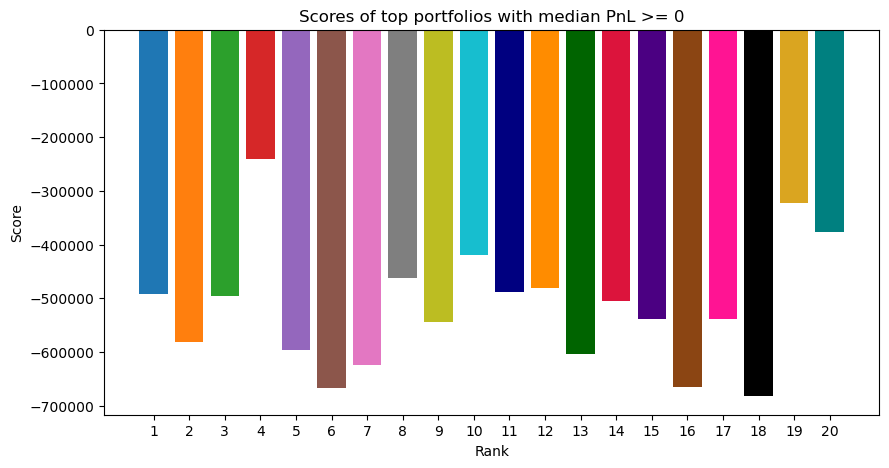

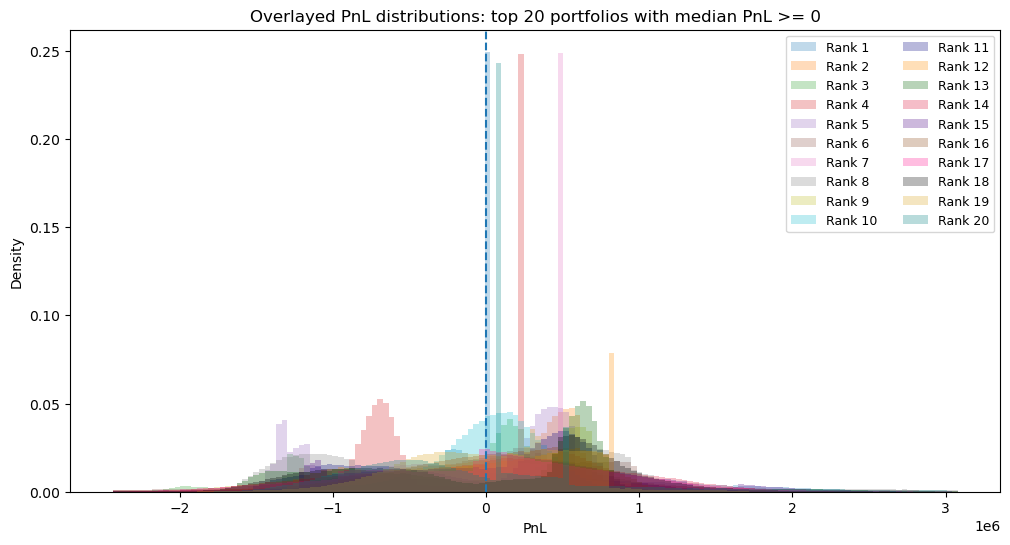

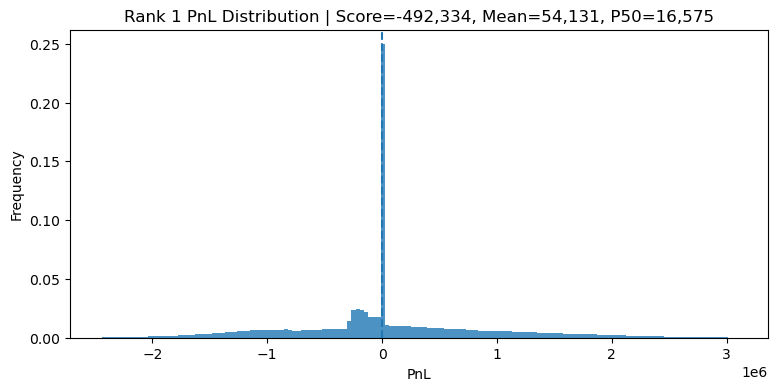

Rank 1
Orders:
AC_50_P: BUY 10 | AC_50_C: BUY 20 | AC_35_P: SELL 5 | AC_40_P: SELL 40 | AC_45_P: BUY 15 | AC_60_C: SELL 10 | AC_50_P_2: BUY 35 | AC_50_CO: SELL 10 | AC_40_BP: SELL 35 | AC_45_KO: BUY 125

Statistics:
score: -492,334.12
mean:  54,130.54
std:   870,879.03
p50:   16,575.00
p10:   -1,061,226.41
p5:    -1,392,653.98
p1:    -1,983,011.62
min:   -3,546,156.11
max:   4,937,036.12
delta: -2,481.76
AC hedge qty: 0
prop_negative:            40.6416%
mode_center:              -4,423.35
mode_bin_mass:            25.4470%
mode_window:              87,087.90
mode_window_mass:         30.4910%
mode_to_median_distance:  20,998.35
mode_to_mean_distance:    58,553.89



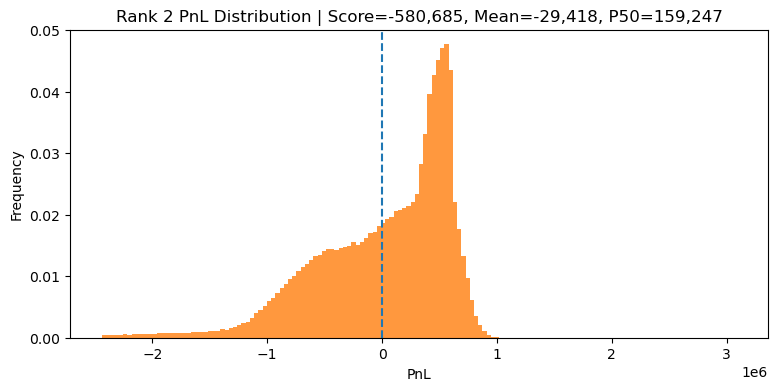

Rank 2
Orders:
AC_50_P: SELL 5 | AC_50_C: BUY 5 | AC_35_P: SELL 30 | AC_40_P: BUY 40 | AC_45_P: SELL 30 | AC_60_C: SELL 15 | AC_50_P_2: BUY 5 | AC_40_BP: BUY 15 | AC_45_KO: SELL 50

Statistics:
score: -580,685.18
mean:  -29,418.14
std:   728,577.32
p50:   159,247.31
p10:   -817,054.80
p5:    -1,105,522.80
p1:    -2,748,863.43
min:   -21,264,431.15
max:   1,101,160.53
delta: -5,411.21
AC hedge qty: 0
prop_negative:            41.4374%
mode_center:              486,106.76
mode_bin_mass:            13.6526%
mode_window:              72,857.73
mode_window_mass:         17.7058%
mode_to_median_distance:  326,859.45
mode_to_mean_distance:    515,524.90



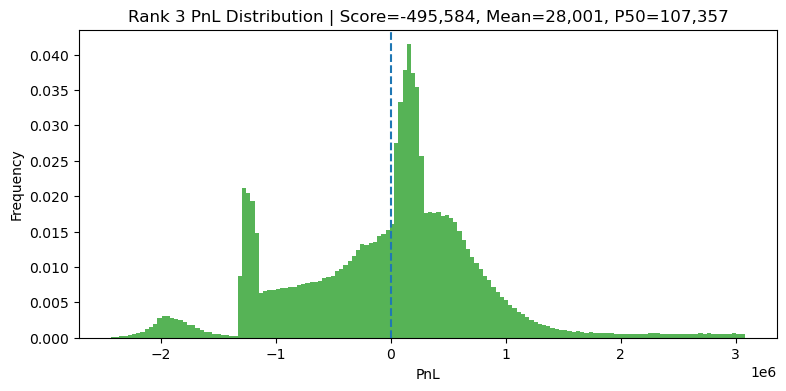

Rank 3
Orders:
AC_50_P: SELL 30 | AC_50_C: SELL 5 | AC_35_P: BUY 40 | AC_40_P: SELL 20 | AC_45_P: BUY 25 | AC_60_C: SELL 5 | AC_50_C_2: SELL 5 | AC_50_CO: BUY 15 | AC_40_BP: SELL 45 | AC_45_KO: BUY 250

Statistics:
score: -495,583.51
mean:  28,000.59
std:   961,317.54
p50:   107,356.58
p10:   -1,200,651.57
p5:    -1,290,815.60
p1:    -2,008,801.99
min:   -3,814,710.42
max:   6,718,328.26
delta: 10,667.11
AC hedge qty: 0
prop_negative:            42.0908%
mode_center:              161,511.68
mode_bin_mass:            6.0020%
mode_window:              96,131.75
mode_window_mass:         19.3984%
mode_to_median_distance:  54,155.10
mode_to_mean_distance:    133,511.09



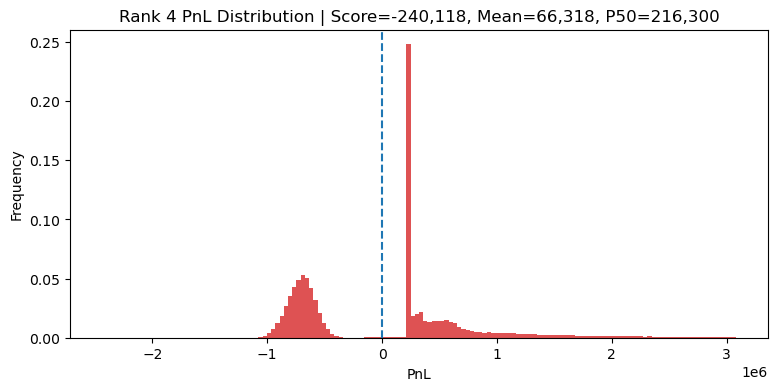

Rank 4
Orders:
AC_50_P: BUY 30 | AC_50_C: BUY 15 | AC_35_P: SELL 20 | AC_45_P: BUY 25 | AC_60_C: BUY 5 | AC_50_P_2: BUY 5 | AC_50_CO: SELL 30 | AC_40_BP: SELL 50 | AC_45_KO: BUY 100 | AC: BUY 10

Statistics:
score: -240,118.03
mean:  66,318.19
std:   859,664.45
p50:   216,300.00
p10:   -788,936.82
p5:    -847,346.91
p1:    -945,994.83
min:   -1,178,539.29
max:   12,926,276.93
delta: 15,121.24
AC hedge qty: 10
prop_negative:            42.3200%
mode_center:              196,680.29
mode_bin_mass:            24.1400%
mode_window:              85,966.45
mode_window_mass:         26.6744%
mode_to_median_distance:  19,619.71
mode_to_mean_distance:    130,362.11



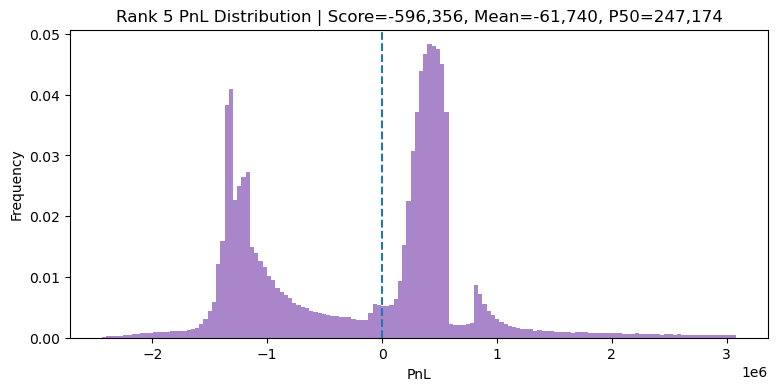

Rank 5
Orders:
AC_50_P: SELL 10 | AC_50_C: SELL 10 | AC_35_P: SELL 50 | AC_40_P: BUY 40 | AC_45_P: BUY 20 | AC_60_C: BUY 30 | AC_50_C_2: BUY 5 | AC_50_CO: SELL 5 | AC_40_BP: BUY 40 | AC_45_KO: SELL 75

Statistics:
score: -596,356.23
mean:  -61,740.14
std:   1,233,599.30
p50:   247,174.40
p10:   -1,334,985.74
p5:    -1,397,560.06
p1:    -1,852,260.77
min:   -2,424,986.08
max:   36,339,977.55
delta: 5,957.22
AC hedge qty: 0
prop_negative:            43.2320%
mode_center:              385,473.78
mode_bin_mass:            23.8562%
mode_window:              123,359.93
mode_window_mass:         29.5636%
mode_to_median_distance:  138,299.38
mode_to_mean_distance:    447,213.92



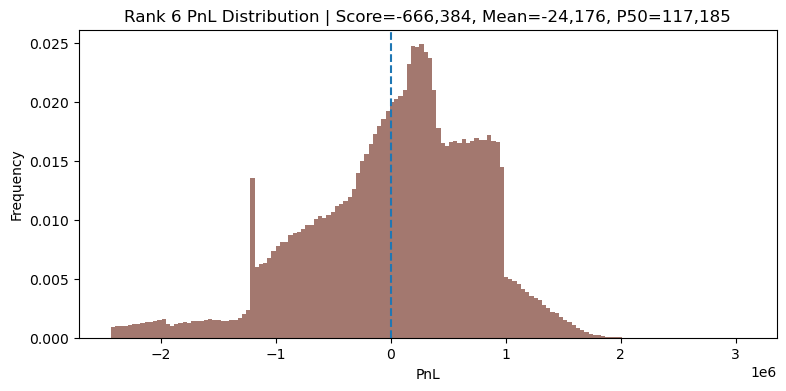

Rank 6
Orders:
AC_50_P: SELL 25 | AC_50_C: BUY 10 | AC_35_P: BUY 15 | AC_40_P: BUY 30 | AC_45_P: SELL 15 | AC_60_C: SELL 30 | AC_50_P_2: SELL 10 | AC_50_CO: BUY 20 | AC_40_BP: SELL 30 | AC_45_KO: SELL 50 | AC: SELL 10

Statistics:
score: -666,384.38
mean:  -24,176.36
std:   868,195.57
p50:   117,184.62
p10:   -1,038,711.27
p5:    -1,459,981.17
p1:    -2,772,127.33
min:   -20,897,381.15
max:   2,308,686.19
delta: -11,141.41
AC hedge qty: -10
prop_negative:            43.5236%
mode_center:              278,155.30
mode_bin_mass:            7.7262%
mode_window:              86,819.56
mode_window_mass:         11.5140%
mode_to_median_distance:  160,970.67
mode_to_mean_distance:    302,331.66



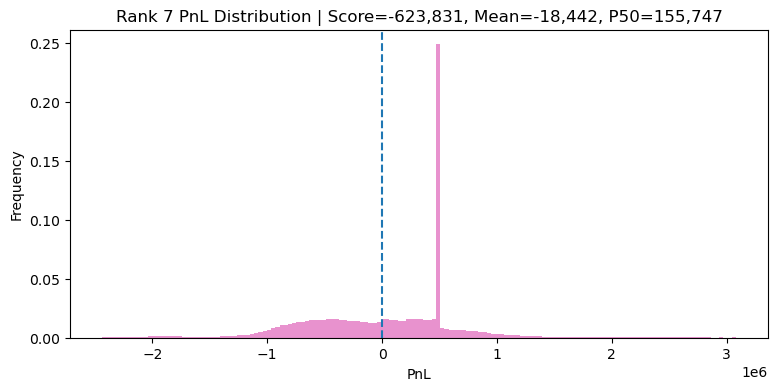

Rank 7
Orders:
AC_50_P: SELL 15 | AC_50_C: SELL 20 | AC_35_P: BUY 15 | AC_40_P: SELL 35 | AC_45_P: SELL 15 | AC_60_C: SELL 10 | AC_50_P_2: BUY 10 | AC_50_CO: BUY 30 | AC_40_BP: SELL 10 | AC_45_KO: BUY 125

Statistics:
score: -623,831.45
mean:  -18,441.77
std:   828,111.94
p50:   155,747.16
p10:   -887,277.37
p5:    -1,254,948.86
p1:    -2,916,524.70
min:   -12,128,814.92
max:   3,782,902.95
delta: 11,109.97
AC hedge qty: 0
prop_negative:            43.5316%
mode_center:              481,221.49
mode_bin_mass:            26.3910%
mode_window:              82,811.19
mode_window_mass:         29.0898%
mode_to_median_distance:  325,474.33
mode_to_mean_distance:    499,663.26



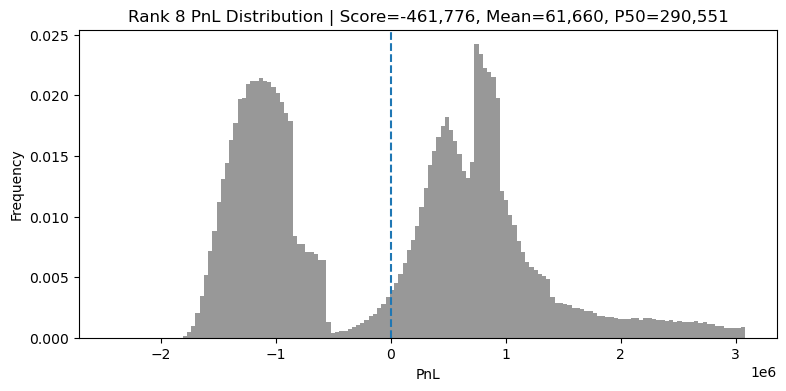

Rank 8
Orders:
AC_50_P: BUY 25 | AC_50_C: BUY 5 | AC_35_P: BUY 10 | AC_40_P: SELL 35 | AC_45_P: BUY 30 | AC_60_C: BUY 20 | AC_50_C_2: SELL 5 | AC_50_CO: SELL 30 | AC_40_BP: SELL 50 | AC_45_KO: BUY 125 | AC: BUY 10

Statistics:
score: -461,776.27
mean:  61,660.49
std:   1,219,239.51
p50:   290,551.09
p10:   -1,336,309.44
p5:    -1,451,404.09
p1:    -1,605,857.43
min:   -3,048,503.14
max:   15,142,486.47
delta: 27,392.06
AC hedge qty: 10
prop_negative:            44.3902%
mode_center:              817,082.15
mode_bin_mass:            5.5624%
mode_window:              121,923.95
mode_window_mass:         14.1834%
mode_to_median_distance:  526,531.06
mode_to_mean_distance:    755,421.66



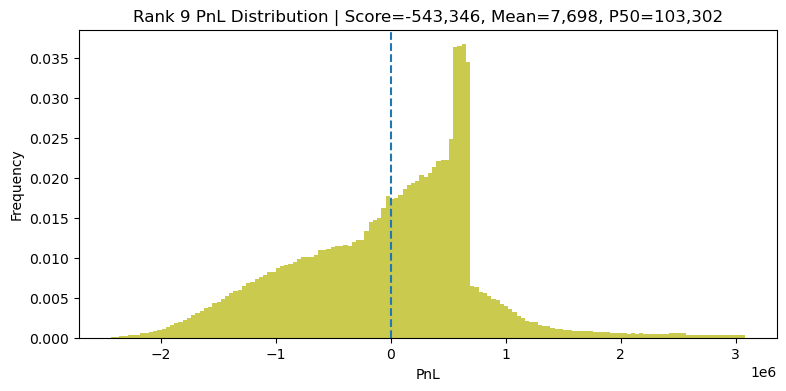

Rank 9
Orders:
AC_50_P: SELL 40 | AC_50_C: BUY 25 | AC_35_P: BUY 35 | AC_40_P: BUY 25 | AC_45_P: BUY 20 | AC_60_C: SELL 10 | AC_50_P_2: SELL 20 | AC_50_CO: SELL 10 | AC_40_BP: SELL 5 | AC_45_KO: BUY 175 | AC: SELL 10

Statistics:
score: -543,346.50
mean:  7,697.88
std:   900,072.78
p50:   103,302.31
p10:   -1,150,689.24
p5:    -1,443,335.74
p1:    -1,902,104.43
min:   -10,250,690.58
max:   5,261,467.55
delta: 14,900.13
AC hedge qty: -10
prop_negative:            45.0834%
mode_center:              646,600.50
mode_bin_mass:            7.7480%
mode_window:              90,007.28
mode_window_mass:         13.8124%
mode_to_median_distance:  543,298.19
mode_to_mean_distance:    638,902.62



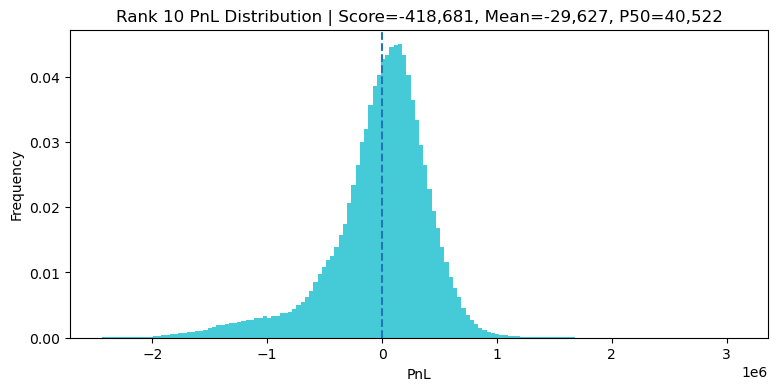

Rank 10
Orders:
AC_50_P: SELL 45 | AC_50_C: SELL 5 | AC_35_P: SELL 35 | AC_40_P: BUY 40 | AC_45_P: BUY 5 | AC_50_P_2: BUY 10 | AC_50_C_2: BUY 5 | AC_50_CO: BUY 10 | AC_40_BP: BUY 5 | AC_45_KO: SELL 50 | AC: SELL 10

Statistics:
score: -418,680.68
mean:  -29,626.56
std:   458,461.71
p50:   40,521.93
p10:   -571,226.76
p5:    -936,832.93
p1:    -1,548,458.84
min:   -6,135,428.26
max:   3,562,778.14
delta: -3,602.53
AC hedge qty: -10
prop_negative:            45.2998%
mode_center:              144,160.38
mode_bin_mass:            5.9192%
mode_window:              45,846.17
mode_window_mass:         11.1386%
mode_to_median_distance:  103,638.45
mode_to_mean_distance:    173,786.95



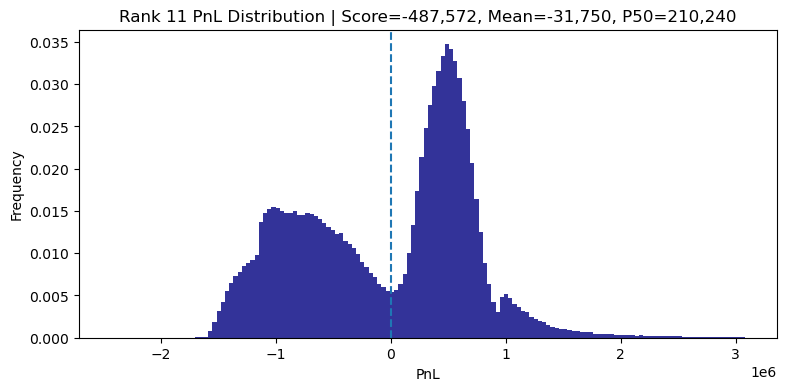

Rank 11
Orders:
AC_50_P: BUY 30 | AC_50_C: BUY 45 | AC_35_P: SELL 20 | AC_40_P: SELL 30 | AC_60_C: SELL 15 | AC_50_P_2: BUY 5 | AC_50_C_2: BUY 10 | AC_50_CO: SELL 10 | AC_40_BP: BUY 25 | AC_45_KO: SELL 75 | AC: SELL 20

Statistics:
score: -487,572.24
mean:  -31,750.12
std:   769,871.77
p50:   210,239.63
p10:   -1,082,813.16
p5:    -1,244,259.32
p1:    -1,447,572.84
min:   -1,728,238.52
max:   13,296,904.04
delta: -4,815.87
AC hedge qty: -20
prop_negative:            45.3478%
mode_center:              487,970.00
mode_bin_mass:            7.0394%
mode_window:              76,987.18
mode_window_mass:         14.0840%
mode_to_median_distance:  277,730.37
mode_to_mean_distance:    519,720.13



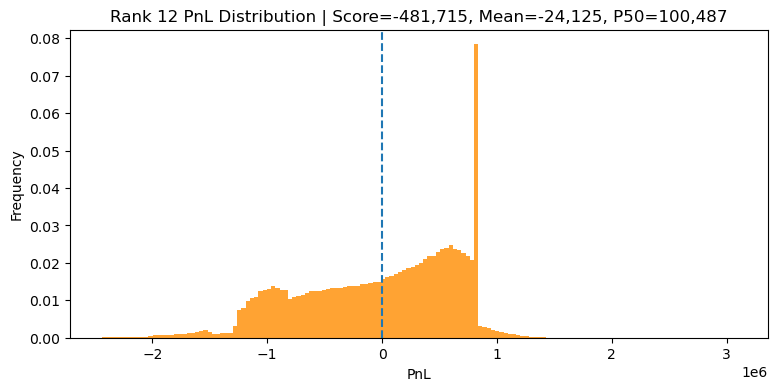

Rank 12
Orders:
AC_50_P: SELL 50 | AC_50_C: SELL 10 | AC_35_P: BUY 30 | AC_40_P: BUY 50 | AC_45_P: SELL 10 | AC_60_C: SELL 5 | AC_50_P_2: SELL 5 | AC_50_CO: BUY 10 | AC_40_BP: SELL 10 | AC_45_KO: SELL 25

Statistics:
score: -481,715.21
mean:  -24,124.97
std:   680,513.03
p50:   100,487.05
p10:   -1,000,931.12
p5:    -1,160,191.36
p1:    -1,675,424.04
min:   -10,110,065.58
max:   1,556,748.21
delta: 850.97
AC hedge qty: 0
prop_negative:            45.5716%
mode_center:              827,572.35
mode_bin_mass:            8.0898%
mode_window:              68,051.30
mode_window_mass:         10.6162%
mode_to_median_distance:  727,085.30
mode_to_mean_distance:    851,697.32



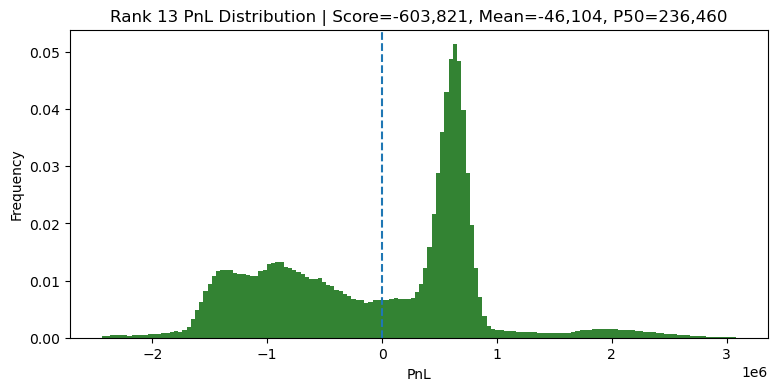

Rank 13
Orders:
AC_50_P: BUY 10 | AC_50_C: BUY 40 | AC_35_P: SELL 50 | AC_40_P: BUY 50 | AC_45_P: BUY 10 | AC_60_C: SELL 20 | AC_50_P_2: BUY 5 | AC_50_C_2: BUY 10 | AC_50_CO: SELL 25 | AC_40_BP: BUY 50 | AC_45_KO: SELL 75

Statistics:
score: -603,821.38
mean:  -46,104.15
std:   925,703.99
p50:   236,460.04
p10:   -1,319,110.19
p5:    -1,477,959.90
p1:    -1,882,272.60
min:   -4,884,412.24
max:   9,305,153.97
delta: -9,933.11
AC hedge qty: 0
prop_negative:            45.6552%
mode_center:              614,044.67
mode_bin_mass:            9.6550%
mode_window:              92,570.40
mode_window_mass:         23.2368%
mode_to_median_distance:  377,584.63
mode_to_mean_distance:    660,148.82



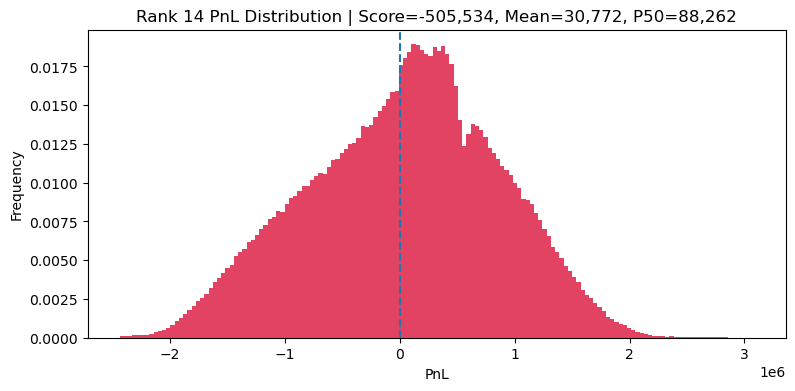

Rank 14
Orders:
AC_50_P: BUY 15 | AC_35_P: SELL 35 | AC_40_P: SELL 30 | AC_45_P: BUY 20 | AC_60_C: BUY 10 | AC_50_P_2: BUY 10 | AC_50_C_2: SELL 10 | AC_50_CO: SELL 5 | AC_40_BP: SELL 40 | AC_45_KO: BUY 50

Statistics:
score: -505,533.89
mean:  30,771.86
std:   839,492.72
p50:   88,261.56
p10:   -1,125,811.19
p5:    -1,410,215.56
p1:    -1,837,518.61
min:   -9,804,503.97
max:   4,611,184.73
delta: 3,928.00
AC hedge qty: 0
prop_negative:            45.6886%
mode_center:              178,360.45
mode_bin_mass:            3.6660%
mode_window:              83,949.27
mode_window_mass:         8.4912%
mode_to_median_distance:  90,098.89
mode_to_mean_distance:    147,588.59



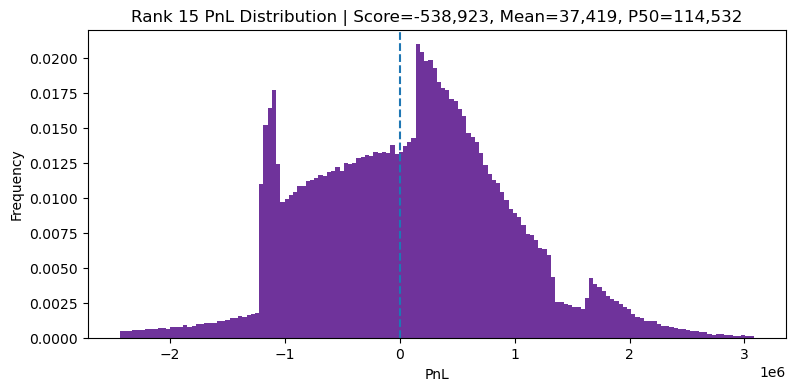

Rank 15
Orders:
AC_50_P: SELL 15 | AC_50_C: BUY 30 | AC_35_P: BUY 15 | AC_40_P: BUY 25 | AC_45_P: BUY 10 | AC_60_C: SELL 20 | AC_50_C_2: SELL 15 | AC_50_CO: SELL 10 | AC_40_BP: SELL 45 | AC_45_KO: BUY 125

Statistics:
score: -538,922.79
mean:  37,418.97
std:   976,660.78
p50:   114,532.15
p10:   -1,087,296.93
p5:    -1,202,419.26
p1:    -2,757,369.48
min:   -20,325,156.06
max:   5,563,335.42
delta: -6,916.79
AC hedge qty: 0
prop_negative:            45.7494%
mode_center:              191,473.44
mode_bin_mass:            7.0268%
mode_window:              97,666.08
mode_window_mass:         10.0308%
mode_to_median_distance:  76,941.28
mode_to_mean_distance:    154,054.46



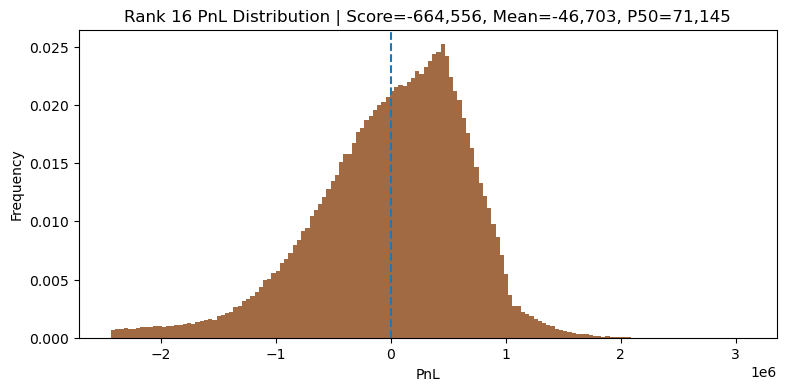

Rank 16
Orders:
AC_50_P: SELL 50 | AC_50_C: SELL 5 | AC_35_P: BUY 10 | AC_40_P: BUY 5 | AC_45_P: BUY 45 | AC_60_C: BUY 5 | AC_50_P_2: SELL 25 | AC_50_C_2: SELL 5 | AC_50_CO: BUY 5 | AC_40_BP: SELL 5 | AC_45_KO: SELL 125 | AC: SELL 10

Statistics:
score: -664,556.17
mean:  -46,702.78
std:   767,811.10
p50:   71,145.36
p10:   -936,827.12
p5:    -1,365,855.98
p1:    -2,763,893.98
min:   -15,306,846.39
max:   2,483,196.44
delta: -4,684.92
AC hedge qty: -10
prop_negative:            45.8506%
mode_center:              392,866.41
mode_bin_mass:            5.9078%
mode_window:              76,781.11
mode_window_mass:         10.2006%
mode_to_median_distance:  321,721.05
mode_to_mean_distance:    439,569.19



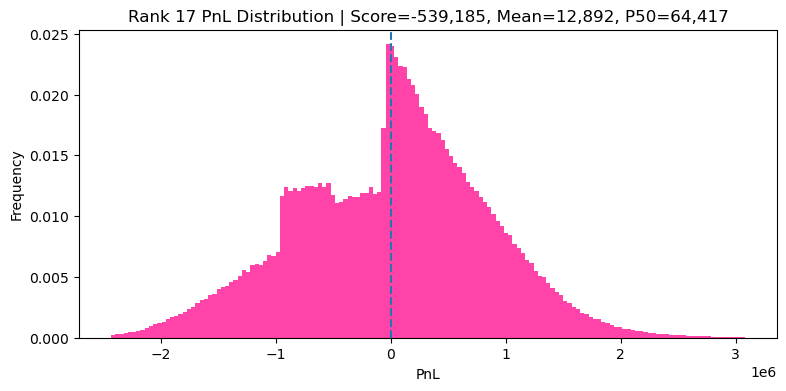

Rank 17
Orders:
AC_50_P: BUY 20 | AC_50_C: BUY 45 | AC_35_P: SELL 30 | AC_40_P: BUY 20 | AC_45_P: BUY 25 | AC_60_C: SELL 25 | AC_50_P_2: SELL 20 | AC_50_CO: SELL 5 | AC_40_BP: SELL 35 | AC_45_KO: BUY 50 | AC: SELL 10

Statistics:
score: -539,184.97
mean:  12,892.42
std:   846,583.42
p50:   64,416.50
p10:   -1,090,364.93
p5:    -1,429,453.44
p1:    -1,947,140.33
min:   -2,914,288.27
max:   10,874,765.58
delta: 6,586.19
AC hedge qty: -10
prop_negative:            45.8982%
mode_center:              15,885.67
mode_bin_mass:            4.4638%
mode_window:              84,658.34
mode_window_mass:         10.6008%
mode_to_median_distance:  48,530.83
mode_to_mean_distance:    2,993.26



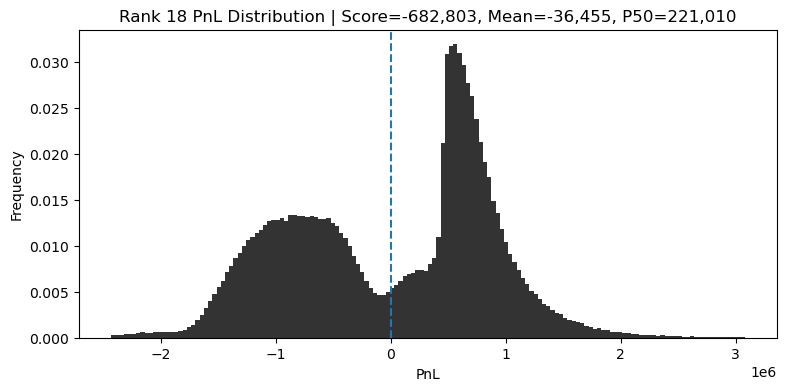

Rank 18
Orders:
AC_50_P: SELL 5 | AC_50_C: BUY 5 | AC_35_P: BUY 35 | AC_40_P: SELL 25 | AC_45_P: SELL 20 | AC_50_P_2: BUY 5 | AC_50_C_2: BUY 5 | AC_50_CO: SELL 5 | AC_40_BP: BUY 15 | AC_45_KO: SELL 150

Statistics:
score: -682,803.06
mean:  -36,455.34
std:   968,677.36
p50:   221,010.46
p10:   -1,245,793.74
p5:    -1,461,839.75
p1:    -2,808,877.83
min:   -4,995,433.75
max:   7,671,677.02
delta: 22,846.02
AC hedge qty: 0
prop_negative:            46.1418%
mode_center:              546,427.21
mode_bin_mass:            5.4648%
mode_window:              96,867.74
mode_window_mass:         16.2794%
mode_to_median_distance:  325,416.76
mode_to_mean_distance:    582,882.55



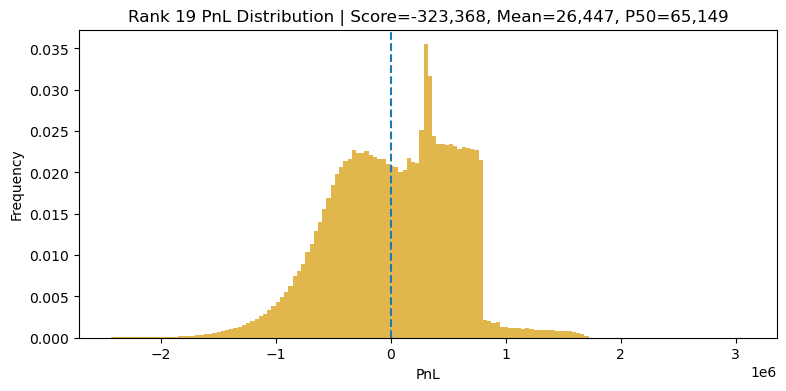

Rank 19
Orders:
AC_50_P: SELL 15 | AC_50_C: BUY 25 | AC_35_P: SELL 30 | AC_45_P: BUY 50 | AC_60_C: SELL 20 | AC_50_P_2: SELL 15 | AC_40_BP: SELL 50 | AC_45_KO: BUY 50 | AC: SELL 10

Statistics:
score: -323,367.94
mean:  26,447.00
std:   547,686.80
p50:   65,149.24
p10:   -667,023.21
p5:    -868,571.77
p1:    -1,326,719.98
min:   -10,138,865.58
max:   1,698,421.98
delta: 10,561.83
AC hedge qty: -10
prop_negative:            46.3420%
mode_center:              307,540.69
mode_bin_mass:            5.6884%
mode_window:              54,768.68
mode_window_mass:         9.2208%
mode_to_median_distance:  242,391.45
mode_to_mean_distance:    281,093.69



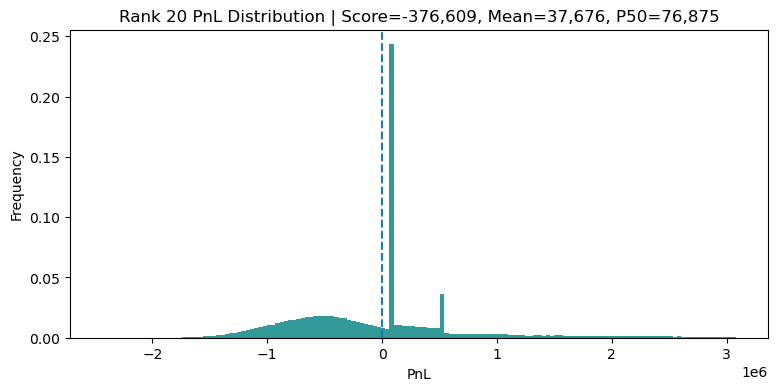

Rank 20
Orders:
AC_50_C: BUY 25 | AC_35_P: BUY 10 | AC_40_P: BUY 5 | AC_45_P: BUY 45 | AC_60_C: BUY 15 | AC_50_P_2: SELL 15 | AC_50_CO: SELL 40 | AC_40_BP: SELL 15 | AC_45_KO: BUY 75

Statistics:
score: -376,609.03
mean:  37,676.46
std:   962,544.22
p50:   76,875.00
p10:   -909,925.68
p5:    -1,096,215.56
p1:    -1,402,316.01
min:   -2,087,416.12
max:   16,910,429.67
delta: 18,017.97
AC hedge qty: 0
prop_negative:            46.5140%
mode_center:              49,841.54
mode_bin_mass:            25.4314%
mode_window:              96,254.42
mode_window_mass:         27.9552%
mode_to_median_distance:  27,033.46
mode_to_mean_distance:    12,165.07



In [25]:
# ============================================================
# Select portfolios with median PnL >= 0,
# rank by score, and display top 20 PnL graphs
# ============================================================

TOP_N = 20

# Choose which result dataframe to use.
# Prefer reranked_results_df if available; otherwise use hedged_results_df.
if "reranked_results_df" in globals() and len(reranked_results_df) > 0:
    source_df = reranked_results_df.copy()
    score_col = "reranked_score"
    print("Using reranked_results_df.")
elif "hedged_results_df" in globals() and len(hedged_results_df) > 0:
    source_df = hedged_results_df.copy()
    score_col = "score"
    print("Using hedged_results_df.")
else:
    raise ValueError("No results dataframe found. Run Step 14 first.")


def clean_positions(positions):
    """Remove zero positions."""
    return {k: v for k, v in positions.items() if v != 0}


def readable_positions(positions):
    """Convert positions into readable order text."""
    positions = clean_positions(positions)

    if len(positions) == 0:
        return "No position"

    parts = []
    for contract, qty in positions.items():
        side = "BUY" if qty > 0 else "SELL"
        parts.append(f"{contract}: {side} {abs(qty)}")

    return " | ".join(parts)


# ============================================================
# Mode concentration utilities
# ============================================================

def mode_concentration_stats(
    pnl,
    bins=200,
    mode_window=None,
    mode_window_frac_of_std=0.10,
):
    """
    Estimate how concentrated the PnL distribution is around its mode.

    Parameters
    ----------
    pnl:
        Array of simulated portfolio PnLs.

    bins:
        Number of histogram bins used to estimate the mode.

    mode_window:
        Absolute distance around the mode center.
        If None, use mode_window_frac_of_std * std(pnl).

    mode_window_frac_of_std:
        If mode_window is None, define:
            mode_window = mode_window_frac_of_std * std(pnl)

    Returns
    -------
    Dictionary with:
        mode_center:
            Estimated mode location from histogram.

        mode_bin_mass:
            Fraction of paths inside the single modal histogram bin.

        mode_window:
            Window used around the mode center.

        mode_window_mass:
            Fraction of paths within mode_center +/- mode_window.

        mode_to_median_distance:
            Distance between mode and median.

        mode_to_mean_distance:
            Distance between mode and mean.
    """
    pnl = np.asarray(pnl)

    counts, edges = np.histogram(pnl, bins=bins)
    mode_bin_idx = np.argmax(counts)

    left_edge = edges[mode_bin_idx]
    right_edge = edges[mode_bin_idx + 1]
    mode_center = 0.5 * (left_edge + right_edge)

    mode_bin_mass = counts[mode_bin_idx] / len(pnl)

    if mode_window is None:
        mode_window = mode_window_frac_of_std * np.std(pnl)

    mode_window_mask = np.abs(pnl - mode_center) <= mode_window
    mode_window_mass = mode_window_mask.mean()

    return {
        "mode_center": mode_center,
        "mode_bin_mass": mode_bin_mass,
        "mode_window": mode_window,
        "mode_window_mass": mode_window_mass,
        "mode_to_median_distance": abs(mode_center - np.percentile(pnl, 50)),
        "mode_to_mean_distance": abs(mode_center - np.mean(pnl)),
    }


# ------------------------------------------------------------
# Compute PnL stats and mode-concentration diagnostics
# ------------------------------------------------------------

MODE_BINS = 200
MODE_WINDOW_FRAC_OF_STD = 0.10

rows = []

for idx, row in source_df.iterrows():
    positions = clean_positions(row["positions"])
    pnl = portfolio_pnl(positions)

    median_pnl = np.percentile(pnl, 50)

    mode_stats = mode_concentration_stats(
        pnl,
        bins=MODE_BINS,
        mode_window=None,
        mode_window_frac_of_std=MODE_WINDOW_FRAC_OF_STD,
    )

    rows.append({
        "source_index": idx,
        "score": row[score_col],

        # usual PnL stats
        "mean": np.mean(pnl),
        "std": np.std(pnl),
        "p50": median_pnl,
        "p10": np.percentile(pnl, 10),
        "p5": np.percentile(pnl, 5),
        "p1": np.percentile(pnl, 1),
        "min": np.min(pnl),
        "max": np.max(pnl),
        "prop_negative": (pnl < 0).mean(),
        "delta": row["delta"] if "delta" in row else portfolio_delta(positions),
        "ac_qty": positions.get("AC", 0),

        # mode concentration diagnostics
        "mode_center": mode_stats["mode_center"],
        "mode_bin_mass": mode_stats["mode_bin_mass"],
        "mode_window": mode_stats["mode_window"],
        "mode_window_mass": mode_stats["mode_window_mass"],
        "mode_to_median_distance": mode_stats["mode_to_median_distance"],
        "mode_to_mean_distance": mode_stats["mode_to_mean_distance"],

        # positions
        "positions": positions,
        "orders": readable_positions(positions),
    })

median_filter_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Filter: median PnL >= 0
# ------------------------------------------------------------

positive_median_df = (
    median_filter_df[median_filter_df["p50"] >= 0]
    .sort_values("prop_negative", ascending=True)
    .reset_index(drop=True)
)

print(f"Number of portfolios with median PnL >= 0: {len(positive_median_df)}")

if len(positive_median_df) == 0:
    print("No portfolios satisfy p50 >= 0.")
else:
    display_cols = [
        "score",
        "mean",
        "std",
        "p50",
        "p10",
        "p5",
        "p1",
        "min",
        "max",
        "prop_negative",
        # mode diagnostics  
        "mode_center",
        "mode_bin_mass",
        "mode_window",
        "mode_window_mass",
        "mode_to_median_distance",
        "mode_to_mean_distance",

        "delta",
        "ac_qty",
        "orders",
    ]

    display(positive_median_df[display_cols].head(TOP_N))


# ------------------------------------------------------------
# Plot PnL distributions for top 20 choices
# ------------------------------------------------------------

if len(positive_median_df) > 0:
    top_df = positive_median_df.head(TOP_N).copy()

    colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive",
        "tab:cyan",
        "navy",
        "darkorange",
        "darkgreen",
        "crimson",
        "indigo",
        "saddlebrown",
        "deeppink",
        "black",
        "goldenrod",
        "teal",
    ]

    top_pnls = []
    labels = []

    for i, row in top_df.iterrows():
        pnl_i = portfolio_pnl(row["positions"])
        top_pnls.append(pnl_i)
        labels.append(f"Rank {i + 1}")

    all_pnl = np.concatenate(top_pnls)

    # Common x-axis range for comparability.
    x_low = np.percentile(all_pnl, 0.5)
    x_high = np.percentile(all_pnl, 99.5)

    # --------------------------------------------------------
    # Graph 1: score bar chart
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))
    plt.bar(
        np.arange(1, len(top_df) + 1),
        top_df["score"].values,
        color=colors[:len(top_df)]
    )
    plt.title("Scores of top portfolios with median PnL >= 0")
    plt.xlabel("Rank")
    plt.ylabel("Score")
    plt.xticks(np.arange(1, len(top_df) + 1))
    plt.show()

    # --------------------------------------------------------
    # Graph 2: overlay PnL distributions
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))

    for i, pnl_i in enumerate(top_pnls):
        plt.hist(
            pnl_i,
            bins=150,
            range=(x_low, x_high),
            weights=np.ones_like(pnl_i) / len(pnl_i),
            alpha=0.28,
            color=colors[i % len(colors)],
            label=labels[i],
        )

    plt.axvline(0, linestyle="--", linewidth=1.5)
    plt.title(f"Overlayed PnL distributions: top {len(top_df)} portfolios with median PnL >= 0")
    plt.xlabel("PnL")
    plt.ylabel("Density")
    plt.legend(ncol=2, fontsize=9)
    plt.show()

    # --------------------------------------------------------
    # Graph 3: separate PnL graphs for each top portfolio
    # --------------------------------------------------------

    for i, row in top_df.iterrows():
        positions = row["positions"]
        pnl_i = portfolio_pnl(positions)

        plt.figure(figsize=(9, 4))
        plt.hist(
            pnl_i,
            bins=150,
            range=(x_low, x_high),
            weights=np.ones_like(pnl_i) / len(pnl_i),
            color=colors[i % len(colors)],
            alpha=0.80,
        )
        plt.axvline(0, linestyle="--", linewidth=1.5)
        plt.title(
            f"Rank {i + 1} PnL Distribution | "
            f"Score={row['score']:,.0f}, Mean={row['mean']:,.0f}, P50={row['p50']:,.0f}"
        )
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()

        print("=" * 100)
        print(f"Rank {i + 1}")
        print("=" * 100)
        print("Orders:")
        print(row["orders"])
        print()
        print("Statistics:")
        print(f"score: {row['score']:,.2f}")
        print(f"mean:  {row['mean']:,.2f}")
        print(f"std:   {row['std']:,.2f}")
        print(f"p50:   {row['p50']:,.2f}")
        print(f"p10:   {row['p10']:,.2f}")
        print(f"p5:    {row['p5']:,.2f}")
        print(f"p1:    {row['p1']:,.2f}")
        print(f"min:   {row['min']:,.2f}")
        print(f"max:   {row['max']:,.2f}")
        print(f"delta: {row['delta']:,.2f}")
        print(f"AC hedge qty: {row['ac_qty']}")
        print(f"prop_negative:            {row['prop_negative']:.4%}")
        print(f"mode_center:              {row['mode_center']:,.2f}")
        print(f"mode_bin_mass:            {row['mode_bin_mass']:.4%}")
        print(f"mode_window:              {row['mode_window']:,.2f}")
        print(f"mode_window_mass:         {row['mode_window_mass']:.4%}")
        print(f"mode_to_median_distance:  {row['mode_to_median_distance']:,.2f}")
        print(f"mode_to_mean_distance:    {row['mode_to_mean_distance']:,.2f}")
        print()

Using hedged_results_df.

Top 10 hedged portfolios with option-only comparison:


,rank,score,hedged_mean,hedged_std,hedged_p10,hedged_p5,hedged_p1,hedged_min,hedged_delta,ac_qty,option_mean,option_std,option_p10,option_p5,option_p1,option_min,option_delta,mean_change_from_hedge,p5_change_from_hedge,p1_change_from_hedge,delta_change_from_hedge,hedged_positions,option_only_positions
0,1,-217235.155425,12252.859137,6.715216e+05,-485346.221164,-5.925562e+05,-8.134897e+05,-3.270202e+06,16912.930185,-10,12401.947625,1.432070e+06,-1.185323e+06,-1.311487e+06,-1.484453e+06,-1.896520e+06,46912.930185,-149.088488,718930.458807,6.709631e+05,-30000.0,AC_50_P: SELL 25 | AC_50_C: BUY 15 | AC_35_P: ...,AC_50_P: SELL 25 | AC_50_C: BUY 15 | AC_35_P: ...
1,2,-222730.455487,3971.169853,5.540590e+05,-524197.400077,-6.246408e+05,-7.054143e+05,-1.235993e+06,2069.501298,-10,4120.258341,1.266574e+06,-1.167142e+06,-1.389772e+06,-1.685667e+06,-2.173797e+06,32069.501298,-149.088488,765131.329501,9.802526e+05,-30000.0,AC_50_P: SELL 5 | AC_50_C: BUY 10 | AC_35_P: S...,AC_50_P: SELL 5 | AC_50_C: BUY 10 | AC_35_P: S...
2,3,-224398.673742,25556.069229,5.626239e+05,-615736.809222,-6.958334e+05,-7.599639e+05,-4.036537e+06,12866.742710,0,25556.069229,5.626239e+05,-6.157368e+05,-6.958334e+05,-7.599639e+05,-4.036537e+06,12866.742710,0.000000,0.000000,0.000000e+00,0.0,AC_50_P: BUY 15 | AC_50_C: BUY 10 | AC_35_P: B...,AC_50_P: BUY 15 | AC_50_C: BUY 10 | AC_35_P: B...
3,4,-238479.337867,29496.561039,6.891115e+05,-591215.346052,-6.687922e+05,-1.007779e+06,-3.851062e+06,18473.745727,0,29496.561039,6.891115e+05,-5.912153e+05,-6.687922e+05,-1.007779e+06,-3.851062e+06,18473.745727,0.000000,0.000000,0.000000e+00,0.0,AC_50_P: BUY 15 | AC_50_C: BUY 30 | AC_35_P: S...,AC_50_P: BUY 15 | AC_50_C: BUY 30 | AC_35_P: S...
4,5,-240118.025586,66318.185379,8.596645e+05,-788936.820548,-8.473469e+05,-9.459948e+05,-1.178539e+06,15121.235947,10,67669.096891,1.053343e+06,-9.725668e+05,-1.674062e+06,-3.440800e+06,-2.195758e+07,-14878.764053,-1350.911512,826714.949886,2.494805e+06,30000.0,AC_50_P: BUY 30 | AC_50_C: BUY 15 | AC_35_P: S...,AC_50_P: BUY 30 | AC_50_C: BUY 15 | AC_35_P: S...
5,6,-241923.707562,34105.959421,9.300625e+05,-635813.607144,-7.339256e+05,-9.254826e+05,-6.157328e+06,10971.400405,-10,34255.047910,1.294268e+06,-1.081038e+06,-1.161080e+06,-1.282486e+06,-1.521568e+06,40971.400405,-149.088488,427154.611298,3.570038e+05,-30000.0,AC_50_P: BUY 25 | AC_50_C: BUY 40 | AC_35_P: B...,AC_50_P: BUY 25 | AC_50_C: BUY 40 | AC_35_P: B...
6,7,-242909.066144,26609.671837,7.437902e+05,-562401.957479,-6.539500e+05,-1.060312e+06,-6.348053e+06,8976.411256,-10,26758.760326,1.206736e+06,-1.417665e+06,-1.600592e+06,-1.843105e+06,-2.296391e+06,38976.411256,-149.088488,946641.589243,7.827929e+05,-30000.0,AC_50_P: SELL 25 | AC_50_C: SELL 15 | AC_35_P:...,AC_50_P: SELL 25 | AC_50_C: SELL 15 | AC_35_P:...
7,8,-269964.341092,-17206.152591,4.826907e+05,-449674.348861,-6.133647e+05,-9.941702e+05,-1.711521e+06,-3707.046810,-10,-17057.064102,9.190289e+05,-9.193241e+05,-1.049064e+06,-1.338136e+06,-2.160629e+06,26292.953190,-149.088488,435699.663717,3.439656e+05,-30000.0,AC_50_P: SELL 15 | AC_50_C: SELL 10 | AC_35_P:...,AC_50_P: SELL 15 | AC_50_C: SELL 10 | AC_35_P:...
8,9,-271636.763581,52723.484896,1.813980e+06,-900675.000000,-9.006750e+05,-9.919150e+05,-1.923557e+06,11761.136353,0,52723.484896,1.813980e+06,-9.006750e+05,-9.006750e+05,-9.919150e+05,-1.923557e+06,11761.136353,0.000000,0.000000,0.000000e+00,0.0,AC_50_P: BUY 20 | AC_50_C: SELL 15 | AC_35_P: ...,AC_50_P: BUY 20 | AC_50_C: SELL 15 | AC_35_P: ...
9,10,-282074.719988,35925.145860,1.400885e+06,-803976.599694,-8.763341e+05,-9.891633e+05,-1.182446e+06,34300.983446,-10,36074.234349,2.100146e+06,-1.419446e+06,-1.479711e+06,-1.582514e+06,-1.829839e+06,64300.983446,-149.088488,603376.636345,5.933508e+05,-30000.0,AC_50_P: BUY 15 | AC_50_C: BUY 5 | AC_35_P: BU...,AC_50_P: BUY 15 | AC_50_C: BUY 5 | AC_35_P: BU...



Rank 1
score: -217,235.16
AC hedge quantity: -10

Option-only positions:
  AC_50_P: SELL 25
  AC_50_C: BUY 15
  AC_35_P: SELL 50
  AC_40_P: BUY 45
  AC_45_P: BUY 20
  AC_60_C: SELL 5
  AC_50_P_2: BUY 5
  AC_50_C_2: BUY 15
  AC_50_CO: SELL 5
  AC_40_BP: SELL 10
  AC_45_KO: BUY 50

Hedged positions:
  AC_50_P: SELL 25
  AC_50_C: BUY 15
  AC_35_P: SELL 50
  AC_40_P: BUY 45
  AC_45_P: BUY 20
  AC_60_C: SELL 5
  AC_50_P_2: BUY 5
  AC_50_C_2: BUY 15
  AC_50_CO: SELL 5
  AC_40_BP: SELL 10
  AC_45_KO: BUY 50
  AC: SELL 10

Option-only stats:
  mean: 12,401.95
  std: 1,432,070.26
  p10: -1,185,322.67
  p5: -1,311,486.62
  p1: -1,484,452.81
  min: -1,896,520.42
  delta: 46,912.93
  sharpe_like: 0.01

Hedged stats:
  mean: 12,252.86
  std: 671,521.64
  p10: -485,346.22
  p5: -592,556.16
  p1: -813,489.74
  min: -3,270,201.51
  delta: 16,912.93
  sharpe_like: 0.02

Rank 2
score: -222,730.46
AC hedge quantity: -10

Option-only positions:
  AC_50_P: SELL 5
  AC_50_C: BUY 10
  AC_35_P: SELL 25
  AC_

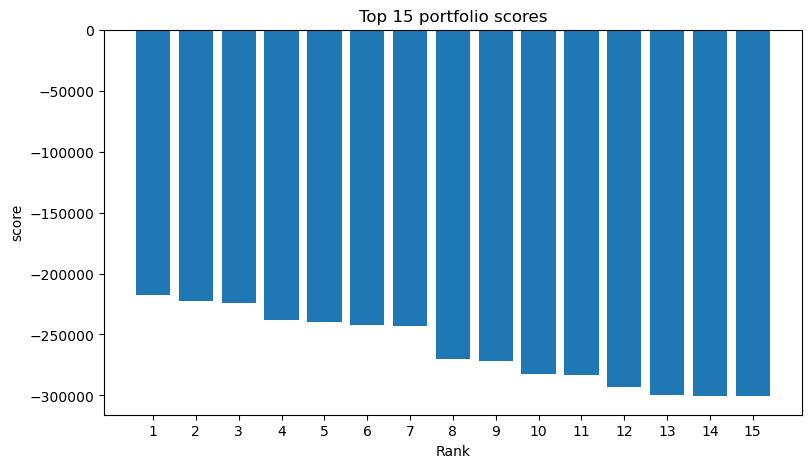

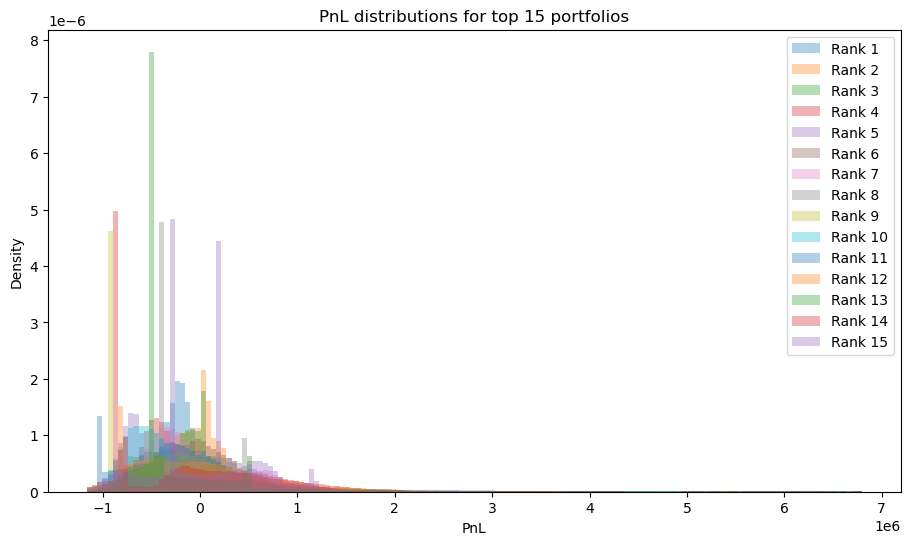

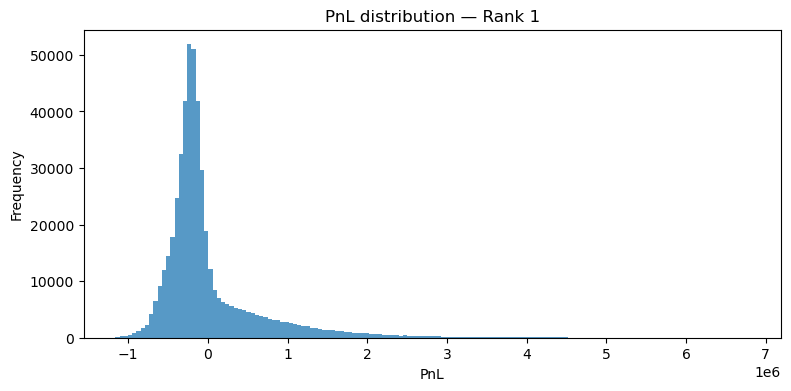


Rank 1 PnL summary:


count    5.000000e+05
mean     1.225286e+04
std      6.715223e+05
min     -3.270202e+06
1%      -8.134897e+05
5%      -5.925562e+05
10%     -4.853462e+05
50%     -1.785908e+05
90%      8.157547e+05
95%      1.365510e+06
99%      2.671997e+06
max      1.693229e+07
dtype: float64

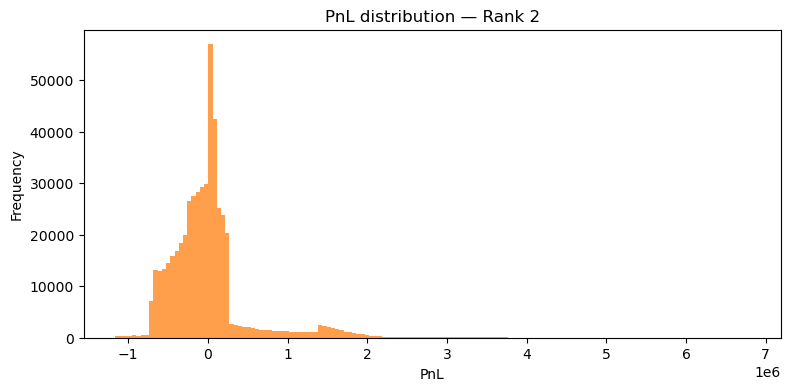


Rank 2 PnL summary:


count    5.000000e+05
mean     3.971170e+03
std      5.540596e+05
min     -1.235993e+06
1%      -7.054143e+05
5%      -6.246408e+05
10%     -5.241974e+05
50%     -4.139214e+04
90%      3.559524e+05
95%      1.217633e+06
99%      1.988426e+06
max      1.182288e+07
dtype: float64

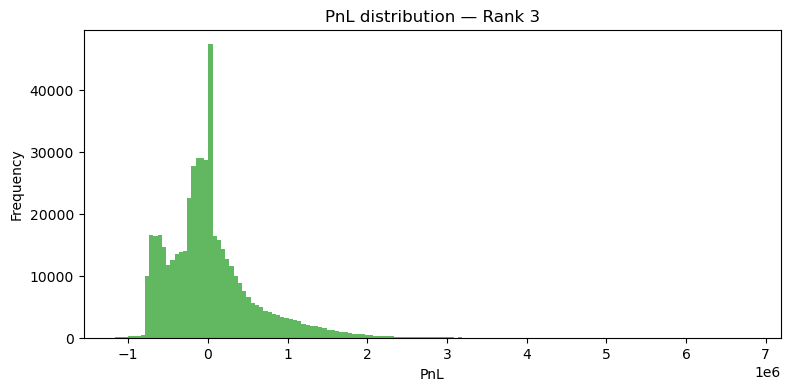


Rank 3 PnL summary:


count    5.000000e+05
mean     2.555607e+04
std      5.626244e+05
min     -4.036537e+06
1%      -7.599639e+05
5%      -6.958334e+05
10%     -6.157368e+05
50%     -4.727193e+04
90%      7.515194e+05
95%      1.141829e+06
99%      1.892487e+06
max      1.015303e+07
dtype: float64

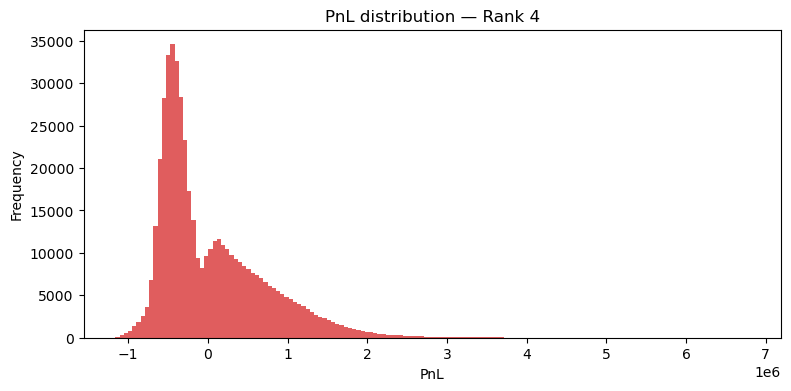


Rank 4 PnL summary:


count    5.000000e+05
mean     2.949656e+04
std      6.891121e+05
min     -3.851062e+06
1%      -1.007779e+06
5%      -6.687922e+05
10%     -5.912153e+05
50%     -2.200375e+05
90%      1.007226e+06
95%      1.357780e+06
99%      2.105501e+06
max      1.033850e+07
dtype: float64

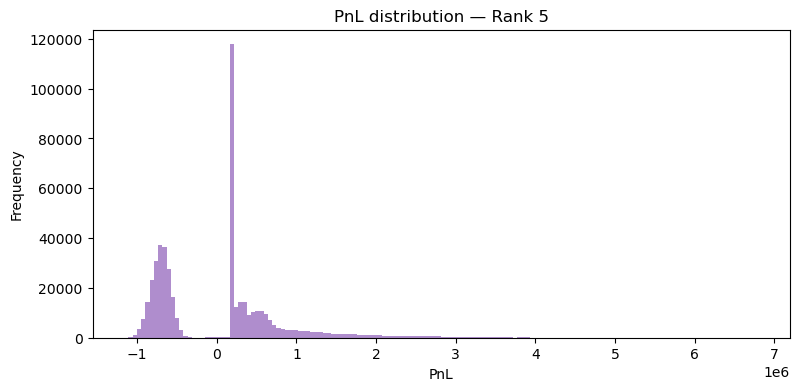


Rank 5 PnL summary:


count    5.000000e+05
mean     6.631819e+04
std      8.596653e+05
min     -1.178539e+06
1%      -9.459948e+05
5%      -8.473469e+05
10%     -7.889368e+05
50%      2.163000e+05
90%      1.013327e+06
95%      1.661494e+06
99%      2.959780e+06
max      1.292628e+07
dtype: float64

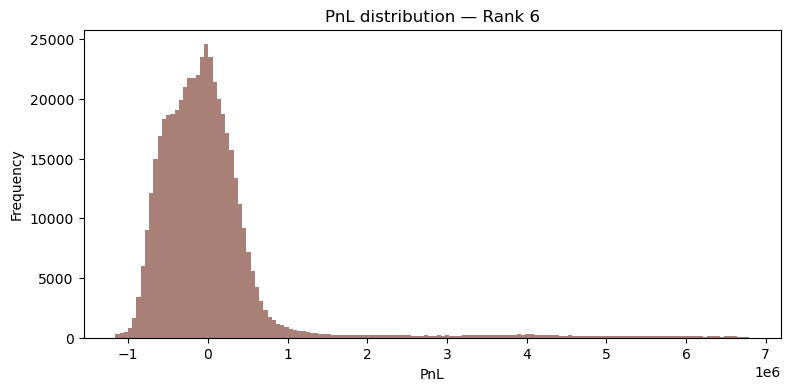


Rank 6 PnL summary:


count    5.000000e+05
mean     3.410596e+04
std      9.300634e+05
min     -6.157328e+06
1%      -9.254826e+05
5%      -7.339256e+05
10%     -6.358136e+05
50%     -9.898372e+04
90%      4.975278e+05
95%      9.151540e+05
99%      4.958730e+06
max      8.055117e+06
dtype: float64

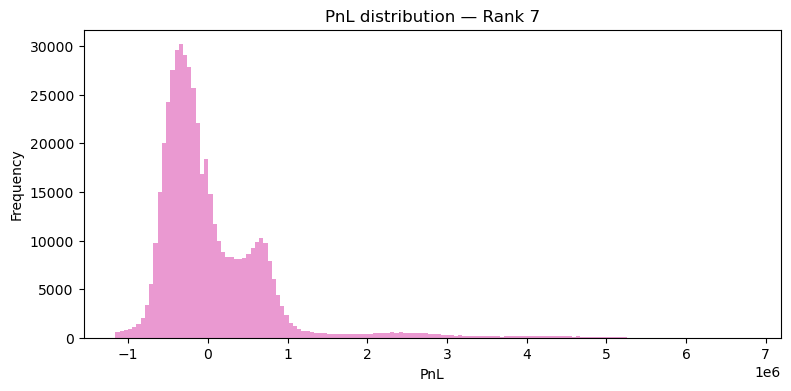


Rank 7 PnL summary:


count    5.000000e+05
mean     2.660967e+04
std      7.437910e+05
min     -6.348053e+06
1%      -1.060312e+06
5%      -6.539500e+05
10%     -5.624020e+05
50%     -1.724134e+05
90%      7.459670e+05
95%      1.033938e+06
99%      3.247729e+06
max      5.776162e+06
dtype: float64

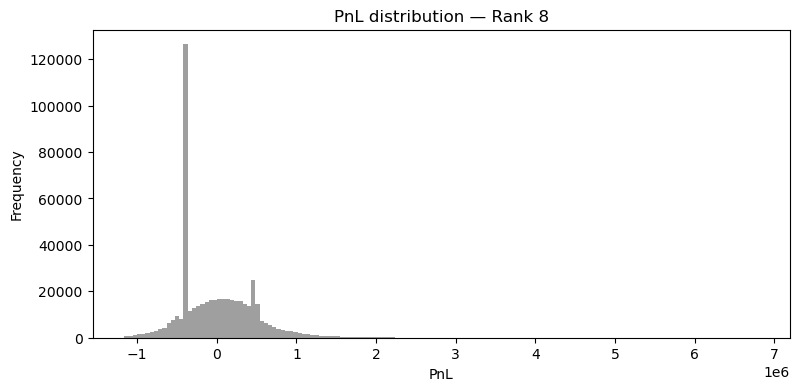


Rank 8 PnL summary:


count    5.000000e+05
mean    -1.720615e+04
std      4.826912e+05
min     -1.711521e+06
1%      -9.941702e+05
5%      -6.133647e+05
10%     -4.496743e+05
50%     -9.546103e+04
90%      5.589737e+05
95%      8.181869e+05
99%      1.437395e+06
max      3.759823e+06
dtype: float64

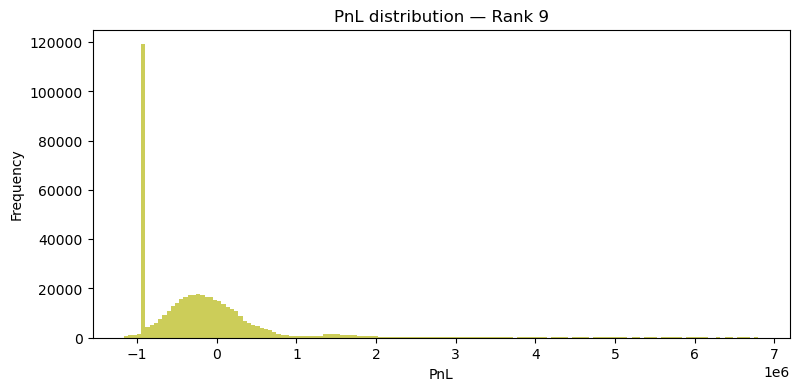


Rank 9 PnL summary:


count    5.000000e+05
mean     5.272348e+04
std      1.813982e+06
min     -1.923557e+06
1%      -9.919150e+05
5%      -9.006750e+05
10%     -9.006750e+05
50%     -2.971082e+05
90%      6.605293e+05
95%      1.784820e+06
99%      1.024734e+07
max      1.559889e+07
dtype: float64

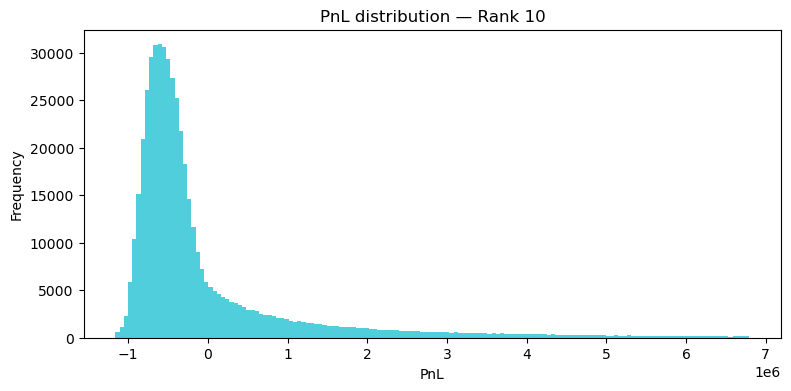


Rank 10 PnL summary:


count    5.000000e+05
mean     3.592515e+04
std      1.400887e+06
min     -1.182446e+06
1%      -9.891633e+05
5%      -8.763341e+05
10%     -8.039766e+05
50%     -4.399488e+05
90%      1.473375e+06
95%      2.984770e+06
99%      6.402692e+06
max      2.581183e+07
dtype: float64

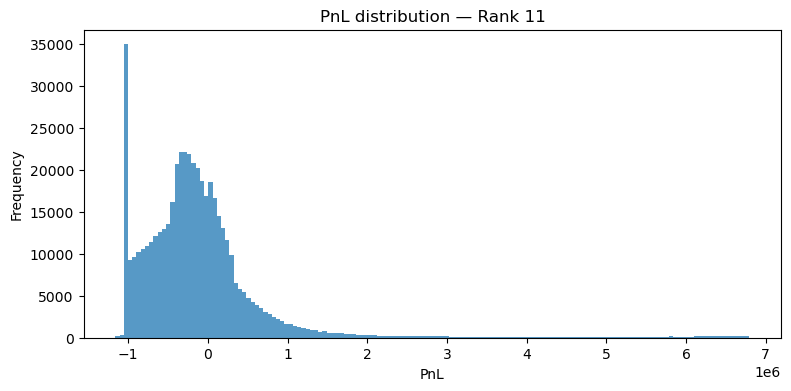


Rank 11 PnL summary:


count    5.000000e+05
mean     8.062883e+04
std      1.577702e+06
min     -4.233412e+06
1%      -1.039500e+06
5%      -1.039500e+06
10%     -9.269735e+05
50%     -2.144653e+05
90%      7.176585e+05
95%      1.693207e+06
99%      8.574642e+06
max      1.418570e+07
dtype: float64

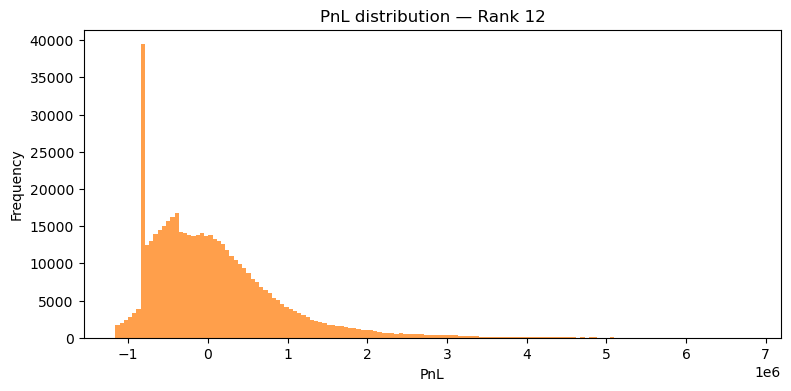


Rank 12 PnL summary:


count    5.000000e+05
mean     4.607149e+04
std      8.601623e+05
min     -2.541021e+06
1%      -1.304745e+06
5%      -8.352657e+05
10%     -8.168250e+05
50%     -1.036684e+05
90%      1.066299e+06
95%      1.599918e+06
99%      2.965661e+06
max      2.105781e+07
dtype: float64

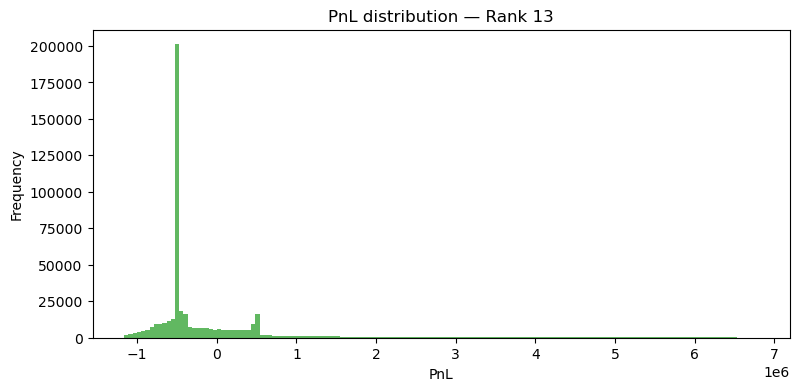


Rank 13 PnL summary:


count    5.000000e+05
mean     3.838517e+04
std      1.539375e+06
min     -3.332074e+06
1%      -1.219459e+06
5%      -8.658749e+05
10%     -7.045826e+05
50%     -5.152500e+05
90%      9.210455e+05
95%      2.765520e+06
99%      7.841346e+06
max      2.686817e+07
dtype: float64

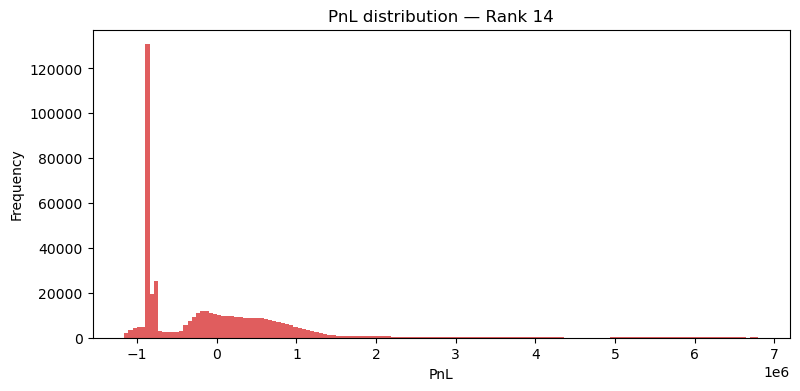


Rank 14 PnL summary:


count    5.000000e+05
mean     2.930536e+04
std      1.273077e+06
min     -1.257784e+06
1%      -1.082636e+06
5%      -8.865000e+05
10%     -8.865000e+05
50%     -1.907130e+05
90%      1.044402e+06
95%      1.751069e+06
99%      6.370410e+06
max      1.182348e+07
dtype: float64

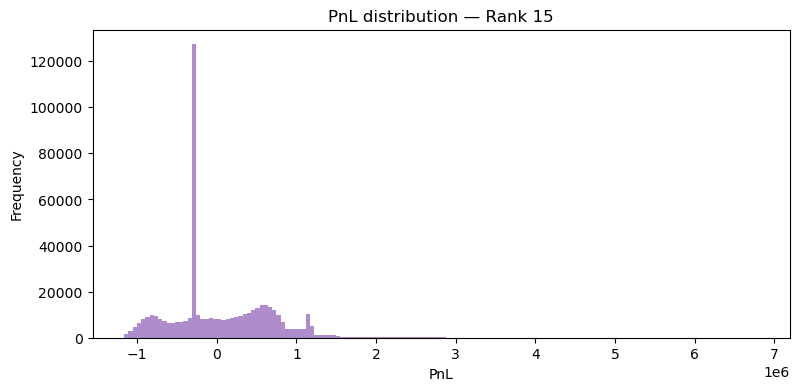


Rank 15 PnL summary:


count    5.000000e+05
mean     3.557966e+04
std      6.707944e+05
min     -1.722656e+06
1%      -1.100355e+06
5%      -9.052477e+05
10%     -7.632435e+05
50%     -2.041882e+05
90%      8.572192e+05
95%      1.152420e+06
99%      1.959249e+06
max      1.023631e+07
dtype: float64

In [17]:
# ============================================================
# Merged Step 15 & 16.
# Inspect top 10 portfolios, compare hedged vs unhedged,
# plot scores, and plot PnL distributions
# ============================================================

TOP_N_TO_INSPECT = 15

# Choose which result dataframe to inspect.
# If you created reranked_results_df, use that.
# Otherwise use hedged_results_df.
if "reranked_results_df" in globals() and len(reranked_results_df) > 0:
    inspect_df = reranked_results_df.copy()
    score_col = "reranked_score"
    print("Using reranked_results_df.")
elif "hedged_results_df" in globals() and len(hedged_results_df) > 0:
    inspect_df = hedged_results_df.copy()
    score_col = "score"
    print("Using hedged_results_df.")
else:
    inspect_df = None
    print("No valid results dataframe available. Run Step 14 first.")


def position_string(positions):
    """
    Convert a position dict into a readable order string.
    """
    nonzero = {k: v for k, v in positions.items() if v != 0}

    if len(nonzero) == 0:
        return "No position"

    parts = []
    for contract, qty in nonzero.items():
        side = "BUY" if qty > 0 else "SELL"
        parts.append(f"{contract}: {side} {abs(qty)}")

    return " | ".join(parts)


def summarize_top_portfolios(inspect_df, score_col, top_n=10):
    """
    Create a readable summary table for the top portfolios.
    """
    rows = []

    for rank, (_, row) in enumerate(inspect_df.head(top_n).iterrows(), start=1):
        hedged_positions = {k: v for k, v in row["positions"].items() if v != 0}
        option_only_positions = {k: v for k, v in hedged_positions.items() if k != "AC"}

        hedged_stats = portfolio_stats(hedged_positions)
        option_stats = portfolio_stats(option_only_positions)

        rows.append({
            "rank": rank,
            "score": row[score_col],
            "hedged_mean": hedged_stats["mean"],
            "hedged_std": hedged_stats["std"],
            "hedged_p10": hedged_stats["p10"],
            "hedged_p5": hedged_stats["p5"],
            "hedged_p1": hedged_stats["p1"],
            "hedged_min": hedged_stats["min"],
            "hedged_delta": hedged_stats["delta"],
            "ac_qty": hedged_positions.get("AC", 0),

            "option_mean": option_stats["mean"],
            "option_std": option_stats["std"],
            "option_p10": option_stats["p10"],
            "option_p5": option_stats["p5"],
            "option_p1": option_stats["p1"],
            "option_min": option_stats["min"],
            "option_delta": option_stats["delta"],

            "mean_change_from_hedge": hedged_stats["mean"] - option_stats["mean"],
            "p5_change_from_hedge": hedged_stats["p5"] - option_stats["p5"],
            "p1_change_from_hedge": hedged_stats["p1"] - option_stats["p1"],
            "delta_change_from_hedge": hedged_stats["delta"] - option_stats["delta"],

            "hedged_positions": position_string(hedged_positions),
            "option_only_positions": position_string(option_only_positions),
        })

    return pd.DataFrame(rows)


if inspect_df is not None:
    top10_df = summarize_top_portfolios(
        inspect_df=inspect_df,
        score_col=score_col,
        top_n=TOP_N_TO_INSPECT,
    )

    print("\nTop 10 hedged portfolios with option-only comparison:")
    display(top10_df)

    # --------------------------------------------------------
    # Print readable order lists for each top portfolio
    # --------------------------------------------------------

    for i in range(min(TOP_N_TO_INSPECT, len(inspect_df))):
        row = inspect_df.iloc[i]
        hedged_positions = {k: v for k, v in row["positions"].items() if v != 0}
        option_only_positions = {k: v for k, v in hedged_positions.items() if k != "AC"}

        print("\n" + "=" * 90)
        print(f"Rank {i + 1}")
        print("=" * 90)

        print(f"{score_col}: {row[score_col]:,.2f}")
        print(f"AC hedge quantity: {hedged_positions.get('AC', 0)}")

        print("\nOption-only positions:")
        for contract, qty in option_only_positions.items():
            side = "BUY" if qty > 0 else "SELL"
            print(f"  {contract}: {side} {abs(qty)}")

        print("\nHedged positions:")
        for contract, qty in hedged_positions.items():
            side = "BUY" if qty > 0 else "SELL"
            print(f"  {contract}: {side} {abs(qty)}")

        print("\nOption-only stats:")
        option_stats = portfolio_stats(option_only_positions)
        for key in ["mean", "std", "p10", "p5", "p1", "min", "delta", "sharpe_like"]:
            print(f"  {key}: {option_stats[key]:,.2f}")

        print("\nHedged stats:")
        hedged_stats = portfolio_stats(hedged_positions)
        for key in ["mean", "std", "p10", "p5", "p1", "min", "delta", "sharpe_like"]:
            print(f"  {key}: {hedged_stats[key]:,.2f}")

    # --------------------------------------------------------
    # Plot scores for top 10
    # --------------------------------------------------------

    score_values = inspect_df.head(TOP_N_TO_INSPECT)[score_col].values
    ranks = np.arange(1, len(score_values) + 1)

    plt.figure(figsize=(9, 5))
    plt.bar(ranks, score_values)
    plt.title(f"Top {len(score_values)} portfolio scores")
    plt.xlabel("Rank")
    plt.ylabel(score_col)
    plt.xticks(ranks)
    plt.show()

    # --------------------------------------------------------
    # Plot PnL distributions for top 10 in one graph
    # --------------------------------------------------------

    colors = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive",
        "tab:cyan",
    ]

    top_pnls = []
    labels = []

    for i in range(min(TOP_N_TO_INSPECT, len(inspect_df))):
        positions = {k: v for k, v in inspect_df.iloc[i]["positions"].items() if v != 0}
        pnl_i = portfolio_pnl(positions)
        top_pnls.append(pnl_i)
        labels.append(f"Rank {i + 1}")

    # Use common x-limits so the comparison is visible.
    all_pnl_concat = np.concatenate(top_pnls)
    x_low = np.percentile(all_pnl_concat, 0.5)
    x_high = np.percentile(all_pnl_concat, 99.5)

    plt.figure(figsize=(11, 6))

    for i, pnl_i in enumerate(top_pnls):
        plt.hist(
            pnl_i,
            bins=150,
            range=(x_low, x_high),
            density=True,
            alpha=0.35,
            color=colors[i % len(colors)],
            label=labels[i],
        )

    plt.title(f"PnL distributions for top {len(top_pnls)} portfolios")
    plt.xlabel("PnL")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # --------------------------------------------------------
    # Alternative: 10 separate PnL graphs, still same colors
    # --------------------------------------------------------

    for i, pnl_i in enumerate(top_pnls):
        plt.figure(figsize=(9, 4))
        plt.hist(
            pnl_i,
            bins=150,
            range=(x_low, x_high),
            color=colors[i % len(colors)],
            alpha=0.75,
        )
        plt.title(f"PnL distribution — Rank {i + 1}")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()

        print(f"\nRank {i + 1} PnL summary:")
        display(
            pd.Series(pnl_i).describe(
                percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]
            )
        )

## Step 16. Plot the PnL distribution of any chosen portfolio

Set `chosen_positions` to the portfolio you want to inspect. By default, this cell uses the best randomized-search portfolio if available.

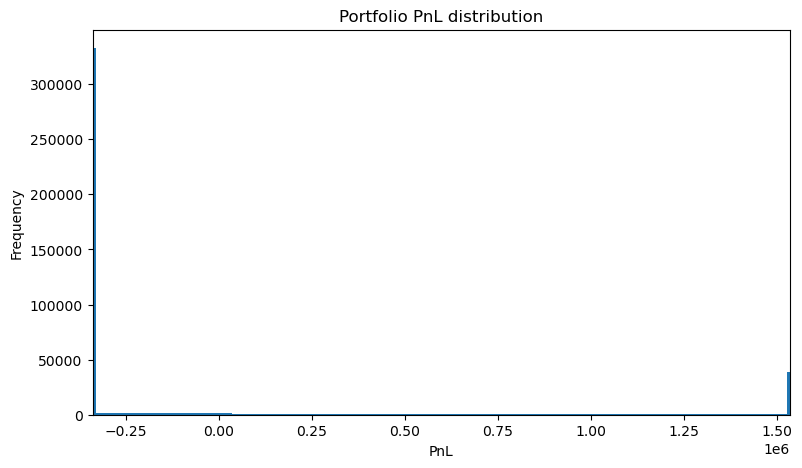

count    5.000000e+05
mean     1.839221e+04
std      6.518853e+05
min     -3.393750e+05
1%      -3.393750e+05
5%      -3.393750e+05
10%     -3.393750e+05
50%     -3.393750e+05
90%      1.410830e+06
95%      1.535625e+06
99%      1.535625e+06
max      1.535625e+06
dtype: float64

In [ ]:
if "hedged_results_df" in globals() and len(hedged_results_df) > 0:
    chosen_positions = {
        k: v
        for k, v in hedged_results_df.iloc[0]["positions"].items()
        if v != 0
    }
else:
    chosen_positions = hedged_naive_positions

pnl = portfolio_pnl(chosen_positions)

plt.figure(figsize=(9, 5))
plt.hist(pnl, bins=200)
plt.title("Portfolio PnL distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.xlim(np.percentile(pnl, 0.5), np.percentile(pnl, 99.5))
plt.show()

pd.Series(pnl).describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

In [1]:
def portfolio_delta_units(positions):
    """
    Delta measured in underlying-equivalent units before contract-size scaling.
    Example: +30 means approximately long 30 units of AC.
    """
    return sum(qty * deltas[name] for name, qty in positions.items())


def portfolio_delta_pnl(positions):
    """
    Delta measured in PnL per 1-unit move in AC after contract-size scaling.
    """
    return CONTRACT_SIZE * portfolio_delta_units(positions)


def option_delta_units_only(positions):
    """
    Option delta before adding AC hedge.
    """
    return sum(
        qty * deltas[name]
        for name, qty in positions.items()
        if name != "AC"
    )

print("option_delta_units_only:", option_delta_units_only(best_positions))
print("total_delta_units:", portfolio_delta_units(best_positions))
print("total_delta_pnl:", portfolio_delta_pnl(best_positions))


NameError: name 'best_positions' is not defined

## Step 17. Manual override: evaluate your own proposed order

Edit the dictionary below and run the cell.

Positive quantity means buy. Negative quantity means sell.

For example:

```python
my_positions = {
    "AC_50_CO": 50,
    "AC_50_C": -50,
    "AC_50_P": -50,
    "AC": 10,
}
```

In [18]:
my_positions = {
    "AC": 0,
    "AC_50_P": 0,
    "AC_50_C": 0,
    "AC_35_P": 0,
    "AC_40_P": 0,
    "AC_45_P": 0,
    "AC_60_C": 0,
    "AC_50_P_2": 0,
    "AC_50_C_2": 0,
    "AC_50_CO": 0,
    "AC_40_BP": 0,
    "AC_45_KO": 0,
}

# Optional: automatically delta hedge with AC.
my_positions_hedged = delta_hedge_with_underlying(my_positions)

display_portfolio("My manually entered portfolio, delta-hedged with AC", my_positions_hedged)

My manually entered portfolio, delta-hedged with AC
Positions:
Stats:
  mean: 0.00
  std: 0.00
  p10: 0.00
  p5: 0.00
  p1: 0.00
  min: 0.00
  delta: 0.00
  sharpe_like: nan


{'mean': np.float64(0.0),
 'std': np.float64(0.0),
 'p10': np.float64(0.0),
 'p5': np.float64(0.0),
 'p1': np.float64(0.0),
 'min': np.float64(0.0),
 'delta': 0,
 'sharpe_like': nan}

# In-depth look